# 📊 Análise Profunda dos Experimentos de Federated Learning

Este notebook realiza uma análise completa e comparativa dos experimentos de Federated Learning usando o framework **LetsFed**.

## 🎯 Objetivos:
- Comparar diferentes **estratégias de treinamento** no cliente (Normal, LetsFed, MaxFL, FedPer, QFFL)
- Avaliar diferentes **métodos de seleção** no servidor (Random, Round Robin, POC, DEEV, LetsFed)
- Analisar diferentes **métodos de agregação** (FedAvg, MaxFL, QFFL)
- Identificar padrões de convergência, fairness e participação dos clientes
- Validar reprodutibilidade dos experimentos

---


## 1️⃣ Importar Bibliotecas e Configuração


In [1]:
# Importar bibliotecas necessárias
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Configurar tamanho padrão das figuras
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

# Exibir todas as colunas do DataFrame
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 100)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2️⃣ Carregar Dados dos Experimentos


In [2]:
# Definir caminho para os logs
logs_path = Path("../logs")

# Criar diretório para salvar as visualizações
output_dir = Path("./outputs")
output_dir.mkdir(exist_ok=True)

print(f"📁 Diretório de saída criado: {output_dir}")


# Função para carregar logs do servidor
def load_server_logs() -> pd.DataFrame:
    """
    Carrega logs do servidor de múltiplos arquivos CSV.

    ⚠️ NOTA: As colunas 'participating_clients_selected' e 'non_participating_clients_selected'
    são removidas durante a leitura pois contêm listas Python que causam problemas de parsing.
    """
    server_files = sorted(logs_path.glob("s-data_*.csv"))
    all_server_data = []

    for file in server_files:
        # Extrair nome do experimento
        experiment = file.stem.replace("s-data_", "")

        # ✅ SOLUÇÃO DEFINITIVA: Ler o CSV linha por linha e remover colunas problemáticas
        with open(file, "r") as f:
            lines = f.readlines()

        if not lines:
            continue

        # Processar header
        header = lines[0].strip().split(",")

        # Identificar índices das colunas problemáticas
        problematic_columns = [
            "participating_clients_selected",
            "non_participating_clients_selected",
        ]

        # Encontrar índices das colunas a remover
        indices_to_remove = [i for i, col in enumerate(header) if col in problematic_columns]

        # Criar novo header sem as colunas problemáticas
        new_header = [col for i, col in enumerate(header) if i not in indices_to_remove]

        # Processar todas as linhas de dados
        new_lines = [",".join(new_header) + "\n"]

        for line in lines[1:]:
            if not line.strip():
                continue

            # Split da linha
            parts = line.strip().split(",")

            # Remover apenas os índices problemáticos (pegar só até onde sabemos que é seguro)
            # Para evitar problemas, vamos pegar apenas as colunas que sabemos que são seguras
            safe_parts = [
                parts[i]
                for i in range(len(parts))
                if i not in indices_to_remove and i < len(header)
            ]

            # Se tiver menos partes que o esperado, preencher
            while len(safe_parts) < len(new_header):
                safe_parts.append("")

            # Se tiver mais, truncar
            safe_parts = safe_parts[: len(new_header)]

            new_lines.append(",".join(safe_parts) + "\n")

        # Criar um arquivo temporário em memória e ler com pandas
        from io import StringIO

        csv_string = "".join(new_lines)
        df = pd.read_csv(StringIO(csv_string))

        df["experiment"] = experiment
        all_server_data.append(df)

    # Concatenar todos os DataFrames
    server_df = pd.concat(all_server_data, ignore_index=True)

    return server_df


# Carregar dados do servidor
server_df = load_server_logs()

print(f"📊 Dados do Servidor carregados: {len(server_df)} registros")
print(f"📁 Experimentos encontrados: {sorted(server_df['experiment'].unique())}")
print(f"📋 Colunas disponíveis: {list(server_df.columns)}")
print(f"📏 Número de colunas: {len(server_df.columns)}")
print("\n🔍 Primeiras linhas:")
display(server_df.head())
print("\n🔍 Últimas linhas:")
display(server_df.tail())

📁 Diretório de saída criado: outputs
📊 Dados do Servidor carregados: 270 registros
📁 Experimentos encontrados: ['letsfed_accuracy_100_thr', 'letsfed_accuracy_90_thr', 'letsfed_f1score_85_thr', 'letsfed_f1score_90_thr', 'letsfed_f1score_90_thr_with_letsfed_agg_num_examples', 'letsfed_f1score_90_thr_with_letsfed_agg_num_examples_weighted_by_interest_metric', 'poc', 'random', 'round_robin']
📋 Colunas disponíveis: ['rounds', 'model_type', 'n_selected', 'selection', 'dataset', 'init_clients', 'participating_state', 'number_of_participating', 'number_of_non_participating', 'training_method', 'aggregation_method', 'selection_method', 'loss', 'accuracy', 'precision', 'recall', 'f1_score', 'auc', 'experiment']
📏 Número de colunas: 19

🔍 Primeiras linhas:


,rounds,model_type,n_selected,selection,dataset,init_clients,participating_state,number_of_participating,number_of_non_participating,training_method,aggregation_method,selection_method,loss,accuracy,precision,recall,f1_score,auc,experiment
0,1,cnn,5,[0;1;2;3;4],fashion_mnist,1.0,[True;True;True;True;True],5,0,letsfed,fedavg,letsfed,1.326665,0.5634,0.716879,0.563338,0.540977,0.962805,letsfed_accuracy_100_thr
1,2,cnn,3,[0;1;2],fashion_mnist,1.0,[False;False;False;True;True],2,3,letsfed,fedavg,letsfed,1.180572,0.6883,0.739615,0.686886,0.665243,0.964256,letsfed_accuracy_100_thr
2,3,cnn,3,[0;1;3],fashion_mnist,1.0,[False;False;False;True;True],2,3,letsfed,fedavg,letsfed,1.028793,0.7433,0.772064,0.741489,0.720742,0.969508,letsfed_accuracy_100_thr
3,4,cnn,3,[2;0;4],fashion_mnist,1.0,[False;False;False;True;True],2,3,letsfed,fedavg,letsfed,0.875426,0.7962,0.803192,0.793599,0.779514,0.977744,letsfed_accuracy_100_thr
4,5,cnn,3,[1;2;3],fashion_mnist,1.0,[False;False;False;True;True],2,3,letsfed,fedavg,letsfed,0.965958,0.7927,0.806610,0.789917,0.775046,0.975479,letsfed_accuracy_100_thr



🔍 Últimas linhas:


,rounds,model_type,n_selected,selection,dataset,init_clients,participating_state,number_of_participating,number_of_non_participating,training_method,aggregation_method,selection_method,loss,accuracy,precision,recall,f1_score,auc,experiment
265,26,cnn,3,[4;2;1],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,round_robin,0.380163,0.8582,0.883304,0.857302,0.853686,0.991070,round_robin
266,27,cnn,3,[4;1;3],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,round_robin,0.321359,0.8801,0.893745,0.878864,0.880029,0.992322,round_robin
267,28,cnn,3,[2;0;4],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,round_robin,0.347495,0.8708,0.890655,0.870315,0.868047,0.991697,round_robin
268,29,cnn,3,[0;2;1],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,round_robin,0.362650,0.8635,0.886775,0.863233,0.858735,0.991383,round_robin
269,30,cnn,3,[3;1;0],fashion_mnist,1.0,[True;True;True;True;True],5,0,normal,fedavg,round_robin,0.334613,0.8751,0.893681,0.874376,0.875105,0.992285,round_robin


In [3]:
# Função para carregar logs dos clientes
def load_client_logs() -> pd.DataFrame:
    client_files = sorted(logs_path.glob("c-data-*_*.csv"))

    all_client_data = []

    for file in client_files:
        # Extrair ID do cliente e método do nome do arquivo
        parts = file.stem.split("_")
        client_id = parts[0].replace("c-data-", "")
        experiment = "_".join(parts[1:])

        # ⚠️ SOLUÇÃO CORRETA: Extrair 'name' dos dicionários diretamente da linha
        import re

        data_rows = []
        with open(file, "r") as f:
            # Ler header
            header = f.readline().strip().split(",")

            # Processar cada linha
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # Encontrar os 3 valores de 'name' nos dicionários
                # Padrão: 'name': 'VALOR'
                name_matches = re.findall(r"'name':\s*'([^']+)'", line)

                if len(name_matches) >= 3:
                    # Pegar os 3 últimos (training, aggregation, selection)
                    dict_names = name_matches[-3:]

                    # Remover tudo após eval_test_loss (última coluna numérica antes dos dicts)
                    # Pegar só as 25 primeiras colunas (todas numéricas/booleanas)
                    match = re.match(r"^((?:[^,]*,){24}[^,]*),", line)
                    if match:
                        numeric_part = match.group(1)
                        normal_cols = numeric_part.split(",")

                        # Combinar com os nomes extraídos
                        row = normal_cols + dict_names
                    else:
                        # Fallback: tentar split normal e pegar primeiras 25 colunas
                        parts = line.split(",")[:25]
                        row = parts + dict_names
                else:
                    # Se não encontrou 3 dicionários, usar split normal
                    row = line.split(",")[: len(header)]

                # Ajustar para o número correto de colunas
                if len(row) > len(header):
                    row = row[: len(header)]
                elif len(row) < len(header):
                    row.extend(["unknown"] * (len(header) - len(row)))

                data_rows.append(row)

        # Criar DataFrame
        df = pd.DataFrame(data_rows, columns=header)

        # Converter tipos de dados
        numeric_cols = [
            "rounds",
            "cid",
            "model_size",
            "model_total_params",
            "model_mean_params",
            "fit_train_accuracy",
            "fit_train_precision",
            "fit_train_recall",
            "fit_train_f1_score",
            "fit_train_auc",
            "fit_train_loss",
            "fit_val_accuracy",
            "fit_val_precision",
            "fit_val_recall",
            "fit_val_f1_score",
            "fit_val_auc",
            "fit_val_loss",
            "eval_test_accuracy",
            "eval_test_precision",
            "eval_test_recall",
            "eval_test_f1_score",
            "eval_test_auc",
            "eval_test_loss",
        ]

        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        # Converter booleanos
        bool_cols = ["participating_state", "selected"]
        for col in bool_cols:
            if col in df.columns:
                df[col] = df[col].map({"True": True, "False": False, True: True, False: False})

        df["experiment"] = experiment
        df["client_id_file"] = int(client_id)
        all_client_data.append(df)

    # Combinar todos os dados
    if all_client_data:
        client_df = pd.concat(all_client_data, ignore_index=True)

        # Reordenar colunas: client_id_file logo no início (após rounds)
        cols = client_df.columns.tolist()

        # Criar nova ordem: começar com as colunas principais
        new_order = ["client_id_file", "experiment", "rounds", "cid"]

        # Adicionar o restante das colunas (exceto as que já estão em new_order)
        remaining_cols = [col for col in cols if col not in new_order]

        # Ordem final
        final_order = new_order + remaining_cols

        # Reordenar o DataFrame
        client_df = client_df[final_order]

        return client_df
    else:
        return None


# Carregar dados dos clientes
client_df = load_client_logs()

if client_df is not None:
    print(f"📊 Dados dos Clientes carregados: {len(client_df)} registros")
    print(f"👥 Clientes únicos: {sorted(client_df['cid'].unique())}")
    print(f"📁 Experimentos encontrados: {sorted(client_df['experiment'].unique())}")
    print("\n🔍 Primeiras linhas:")
    display(client_df)
else:
    print("⚠️ Nenhum dado de cliente encontrado")

📊 Dados dos Clientes carregados: 800 registros
👥 Clientes únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
📁 Experimentos encontrados: ['letsfed_accuracy_100_thr', 'letsfed_accuracy_90_thr', 'letsfed_agg_num_examples_weighted_by_interest_metric', 'letsfed_f1score_85_thr', 'letsfed_f1score_90_thr', 'letsfed_f1score_90_thr_with_letsfed_agg_num_examples', 'poc', 'random', 'round_robin']

🔍 Primeiras linhas:


,client_id_file,experiment,rounds,cid,participating_state,selected,model_size,model_total_params,model_mean_params,fit_train_accuracy,fit_train_precision,fit_train_recall,fit_train_f1_score,fit_train_auc,fit_train_loss,fit_val_accuracy,fit_val_precision,fit_val_recall,fit_val_f1_score,fit_val_auc,fit_val_loss,eval_test_accuracy,eval_test_precision,eval_test_recall,eval_test_f1_score,eval_test_auc,eval_test_loss,training_method,aggregation_method,selection_method,interest_metric
0,0,letsfed_accuracy_100_thr,1,0,True,True,387368,96842,0.307567,0.889154,0.879239,0.823589,0.886634,0.990442,0.564809,0.871748,0.831602,0.803963,0.868235,0.988204,0.510220,0.5610,0.719025,0.558991,0.536178,0.961806,1.322217,letsfed,round_robin,round_robin,unknown
1,0,letsfed_accuracy_100_thr,2,0,False,True,387368,96842,0.490258,0.894742,0.901392,0.826084,0.895037,0.993181,0.422782,0.874313,0.878953,0.808778,0.875008,0.989790,0.357209,0.7890,0.838648,0.788796,0.789673,0.981118,0.608630,letsfed,round_robin,round_robin,unknown
2,0,letsfed_accuracy_100_thr,3,0,False,True,387368,96842,0.517554,0.929095,0.922870,0.879460,0.926993,0.996111,0.340004,0.890436,0.859881,0.832645,0.887427,0.991861,0.322525,0.8370,0.856148,0.837708,0.832648,0.985343,0.522316,letsfed,round_robin,round_robin,unknown
3,0,letsfed_accuracy_100_thr,4,0,False,True,387368,96842,0.458598,0.931019,0.934594,0.889214,0.931363,0.997028,0.307146,0.888237,0.874386,0.831305,0.888651,0.992216,0.305545,0.8250,0.860353,0.824553,0.827746,0.985166,0.516833,letsfed,round_robin,round_robin,unknown
4,0,letsfed_accuracy_100_thr,6,0,False,True,387368,96842,0.579169,0.944852,0.941853,0.915163,0.944577,0.997481,0.283538,0.888970,0.860548,0.830667,0.887903,0.992091,0.298677,0.8345,0.854260,0.835111,0.835275,0.984825,0.502132,letsfed,round_robin,round_robin,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,4,round_robin,22,4,True,True,387368,96842,1.126855,0.957785,0.955691,0.951333,0.957978,0.998431,0.262304,0.902164,0.905002,0.895963,0.902014,0.992554,0.269164,0.8135,0.764053,0.813837,0.781320,0.990511,0.573531,normal,fedavg,round_robin,NaN
796,4,round_robin,25,4,True,True,387368,96842,1.238514,0.958725,0.954767,0.952078,0.958871,0.998316,0.268699,0.903104,0.908430,0.902495,0.903335,0.992546,0.265911,0.8910,0.908521,0.889079,0.894298,0.993850,0.295016,normal,fedavg,round_robin,NaN
797,4,round_robin,26,4,True,True,387368,96842,1.151606,0.961312,0.961608,0.953808,0.961366,0.998415,0.255619,0.909219,0.914177,0.881290,0.908717,0.992836,0.262854,0.8450,0.870664,0.844280,0.834592,0.991008,0.407707,normal,fedavg,round_robin,NaN
798,4,round_robin,27,4,True,True,387368,96842,1.322523,0.962606,0.959241,0.958383,0.962950,0.998579,0.255316,0.905927,0.901794,0.897968,0.906492,0.992310,0.263321,0.8920,0.898461,0.890889,0.893529,0.993771,0.280353,normal,fedavg,round_robin,NaN


## 3️⃣ Estatísticas Gerais e Resumo


In [4]:
# Estatísticas gerais do servidor
print("=" * 80)
print("📈 ESTATÍSTICAS GERAIS DO SERVIDOR")
print("=" * 80)

print("\nTotal de rounds executados por experimento:")
print(server_df.groupby("experiment")["rounds"].max())

print("\n\nMétodos de seleção utilizados:")
print(server_df.groupby("experiment")["selection_method"].first())

print("\n\nMétodos de agregação utilizados:")
print(server_df.groupby("experiment")["aggregation_method"].first())

print("\n\nMétodos de treinamento utilizados:")
print(server_df.groupby("experiment")["training_method"].first())

📈 ESTATÍSTICAS GERAIS DO SERVIDOR

Total de rounds executados por experimento:
experiment
letsfed_accuracy_100_thr                                                            30
letsfed_accuracy_90_thr                                                             30
letsfed_f1score_85_thr                                                              30
letsfed_f1score_90_thr                                                              30
letsfed_f1score_90_thr_with_letsfed_agg_num_examples                                30
letsfed_f1score_90_thr_with_letsfed_agg_num_examples_weighted_by_interest_metric    30
poc                                                                                 30
random                                                                              30
round_robin                                                                         30
Name: rounds, dtype: int64


Métodos de seleção utilizados:
experiment
letsfed_accuracy_100_thr                                

In [5]:
# Resumo estatístico das métricas do servidor
print("\n" + "=" * 80)
print("📊 RESUMO ESTATÍSTICO DAS MÉTRICAS (SERVIDOR)")
print("=" * 80 + "\n")

metrics = ["accuracy", "precision", "recall", "f1_score", "auc", "loss"]

for experiment in sorted(server_df["experiment"].unique()):
    print(f"\n{'=' * 60}")
    print(f"📌 EXPERIMENTO: {experiment.upper()}")
    print(f"{'=' * 60}")

    exp_data = server_df[server_df["experiment"] == experiment]

    summary = exp_data[metrics].describe().T
    summary["final"] = exp_data.groupby("experiment")[metrics].last().T

    display(summary[["mean", "std", "min", "max", "final"]])


📊 RESUMO ESTATÍSTICO DAS MÉTRICAS (SERVIDOR)


📌 EXPERIMENTO: LETSFED_ACCURACY_100_THR


,mean,std,min,max,final
accuracy,0.797470,0.051552,0.563400,0.822900,0.818200
precision,0.806925,0.023322,0.716879,0.819910,0.817422
recall,0.795196,0.051092,0.563338,0.820279,0.816094
f1_score,0.781664,0.053793,0.540977,0.809310,0.804841
auc,0.975969,0.003893,0.962805,0.979236,0.979192
loss,1.126972,0.111055,0.875426,1.326665,1.201953



📌 EXPERIMENTO: LETSFED_ACCURACY_90_THR


,mean,std,min,max,final
accuracy,0.799457,0.050166,0.563400,0.822500,0.817100
precision,0.815498,0.022843,0.716879,0.849030,0.837703
recall,0.797245,0.049712,0.563338,0.820010,0.815130
f1_score,0.783640,0.051312,0.540977,0.808458,0.801991
auc,0.981887,0.004337,0.962805,0.985679,0.984242
loss,0.793807,0.118404,0.536352,1.326665,0.781543



📌 EXPERIMENTO: LETSFED_F1SCORE_85_THR


...

,mean,std,min,max,final
accuracy,0.790310,0.107933,0.253400,0.833300,0.821300
precision,0.804040,0.037613,0.614991,0.822740,0.814847
recall,0.788287,0.107649,0.253517,0.831620,0.819308
f1_score,0.777992,0.107158,0.243450,0.823561,0.810127
auc,0.983277,0.008580,0.940919,0.986329,0.985869
loss,0.700711,0.237456,0.591395,1.899046,0.682435



📌 EXPERIMENTO: RANDOM


,mean,std,min,max,final
accuracy,0.817340,0.074392,0.563400,0.883300,0.872500
precision,0.840759,0.051533,0.716879,0.895912,0.892331
recall,0.816637,0.073846,0.563338,0.881679,0.871591
f1_score,0.803106,0.081880,0.540977,0.880994,0.869525
auc,0.987308,0.006952,0.962805,0.992344,0.992056
loss,0.539861,0.239196,0.321375,1.326665,0.350208



📌 EXPERIMENTO: ROUND_ROBIN


,mean,std,min,max,final
accuracy,0.833510,0.059548,0.563400,0.881300,0.875100
precision,0.856858,0.040633,0.716879,0.893792,0.893681
recall,0.832733,0.059545,0.563338,0.879815,0.874376
f1_score,0.822990,0.063694,0.540977,0.880029,0.875105
auc,0.988727,0.005716,0.962805,0.992322,0.992285
loss,0.472372,0.190666,0.321359,1.326665,0.334613


## 4️⃣ Pré-processamento e Transformação dos Dados


In [6]:
# Processar a coluna 'selection' para extrair lista de clientes selecionados
def parse_selection(selection_str: str) -> list:
    """Converte string '[0;1;2]' em lista [0, 1, 2]"""
    if pd.isna(selection_str):
        return []
    return [int(x) for x in str(selection_str).strip("[]").split(";") if x]


server_df["selected_clients"] = server_df["selection"].apply(parse_selection)
server_df["num_selected"] = server_df["selected_clients"].apply(len)

print("✅ Coluna 'selected_clients' criada")
print("\n📊 Distribuição do número de clientes selecionados por round:")
print(server_df.groupby("experiment")["num_selected"].describe())

✅ Coluna 'selected_clients' criada

📊 Distribuição do número de clientes selecionados por round:
                                                    count      mean       std  \
experiment                                                                      
letsfed_accuracy_100_thr                             30.0  3.066667  0.365148   
letsfed_accuracy_90_thr                              30.0  3.066667  0.365148   
letsfed_f1score_85_thr                               30.0  3.066667  0.365148   
letsfed_f1score_90_thr                               30.0  3.066667  0.365148   
letsfed_f1score_90_thr_with_letsfed_agg_num_exa...   30.0  3.066667  0.365148   
letsfed_f1score_90_thr_with_letsfed_agg_num_exa...   30.0  3.066667  0.365148   
poc                                                  30.0  2.133333  0.571346   
random                                               30.0  3.066667  0.365148   
round_robin                                          30.0  3.066667  0.365148   

           

## 5️⃣ Análise de Convergência


💾 Salvo: topico-5-evolucao-metricas-rounds.png


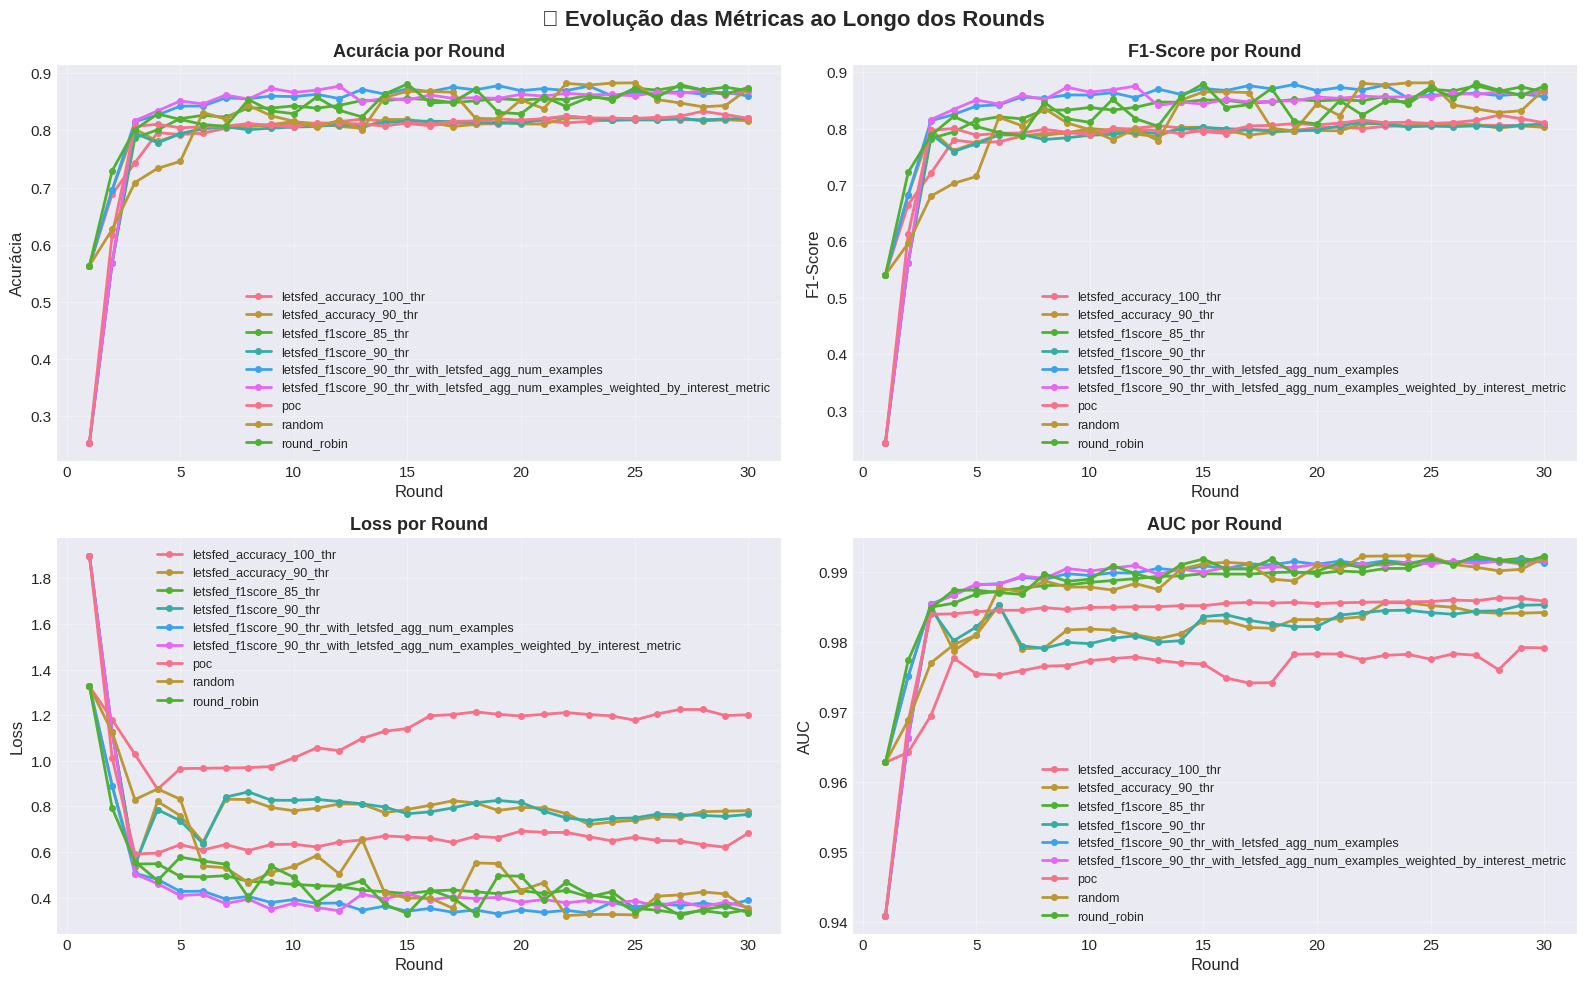


📊 Gráficos de convergência gerados!


In [ ]:
# Plotar evolução da acurácia ao longo dos rounds
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("📈 Evolução das Métricas ao Longo dos Rounds", fontsize=16, fontweight="bold")

metrics_to_plot = [
    ("accuracy", "Acurácia"),
    ("f1_score", "F1-Score"),
    ("loss", "Loss"),
    ("auc", "AUC"),
]

for idx, (metric, label) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    for experiment in sorted(server_df["experiment"].unique()):
        data = server_df[server_df["experiment"] == experiment]
        ax.plot(
            data["rounds"], data[metric], marker="o", label=experiment, linewidth=2, markersize=4
        )

    ax.set_xlabel("Round", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f"{label} por Round", fontsize=13, fontweight="bold")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "topico-5-evolucao-metricas-rounds.png", dpi=300, bbox_inches="tight")
print("💾 Salvo: topico-5-evolucao-metricas-rounds.png")
plt.show()

print("\n📊 Gráficos de convergência gerados!")

🚀 TAXA DE CONVERGÊNCIA (Melhoria de Múltiplas Métricas)

🔍 Iniciando cálculo de convergência...
📊 Total de experimentos a processar: 9

📊 Criando DataFrame de convergência...

📋 Exibindo tabela resumida...


,experiment,num_rounds,accuracy_initial,accuracy_final,accuracy_improvement,precision_initial,precision_final,precision_improvement,recall_initial,recall_final,recall_improvement,f1_score_initial,f1_score_final,f1_score_improvement,auc_initial,auc_final,auc_improvement
8,round_robin,30,0.5634,0.8751,0.3117,0.716879,0.893681,0.176802,0.563338,0.874376,0.311037,0.540977,0.875105,0.334128,0.962805,0.992285,0.029480
7,random,30,0.5634,0.8725,0.3091,0.716879,0.892331,0.175452,0.563338,0.871591,0.308253,0.540977,0.869525,0.328548,0.962805,0.992056,0.029251
5,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,30,0.2534,0.8698,0.6164,0.614991,0.889470,0.274479,0.253517,0.869251,0.615734,0.243450,0.866259,0.622809,0.940919,0.991728,0.050810
2,letsfed_f1score_85_thr,30,0.2534,0.8697,0.6163,0.614991,0.887148,0.272157,0.253517,0.869004,0.615487,0.243450,0.864988,0.621538,0.940919,0.991471,0.050552
4,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,30,0.5634,0.8603,0.2969,0.716879,0.886747,0.169868,0.563338,0.859227,0.295889,0.540977,0.856320,0.315343,0.962805,0.991385,0.028580
3,letsfed_f1score_90_thr,30,0.2534,0.8214,0.5680,0.614991,0.840993,0.226002,0.253517,0.819049,0.565532,0.243450,0.808261,0.564811,0.940919,0.985347,0.044428
6,poc,30,0.2534,0.8213,0.5679,0.614991,0.814847,0.199856,0.253517,0.819308,0.565791,0.243450,0.810127,0.566677,0.940919,0.985869,0.044950
0,letsfed_accuracy_100_thr,30,0.5634,0.8182,0.2548,0.716879,0.817422,0.100543,0.563338,0.816094,0.252755,0.540977,0.804841,0.263864,0.962805,0.979192,0.016388
1,letsfed_accuracy_90_thr,30,0.5634,0.8171,0.2537,0.716879,0.837703,0.120824,0.563338,0.815130,0.251792,0.540977,0.801991,0.261014,0.962805,0.984242,0.021437



💾 Salvando tabela de convergência...
💾 Salvo: topico-5-tabela-convergencia-multiplas-metricas.png

📊 Criando gráficos de comparação...
  📈 Plotando métrica: accuracy
  📈 Plotando métrica: precision
  📈 Plotando métrica: recall
  📈 Plotando métrica: f1_score
  📈 Plotando métrica: auc
💾 Salvo: topico-5-tabela-convergencia-multiplas-metricas.png

📊 Criando gráficos de comparação...
  📈 Plotando métrica: accuracy
  📈 Plotando métrica: precision
  📈 Plotando métrica: recall
  📈 Plotando métrica: f1_score
  📈 Plotando métrica: auc
💾 Salvo: topico-5-comparacao-inicial-final-multiplas-metricas.png
💾 Salvo: topico-5-comparacao-inicial-final-multiplas-metricas.png


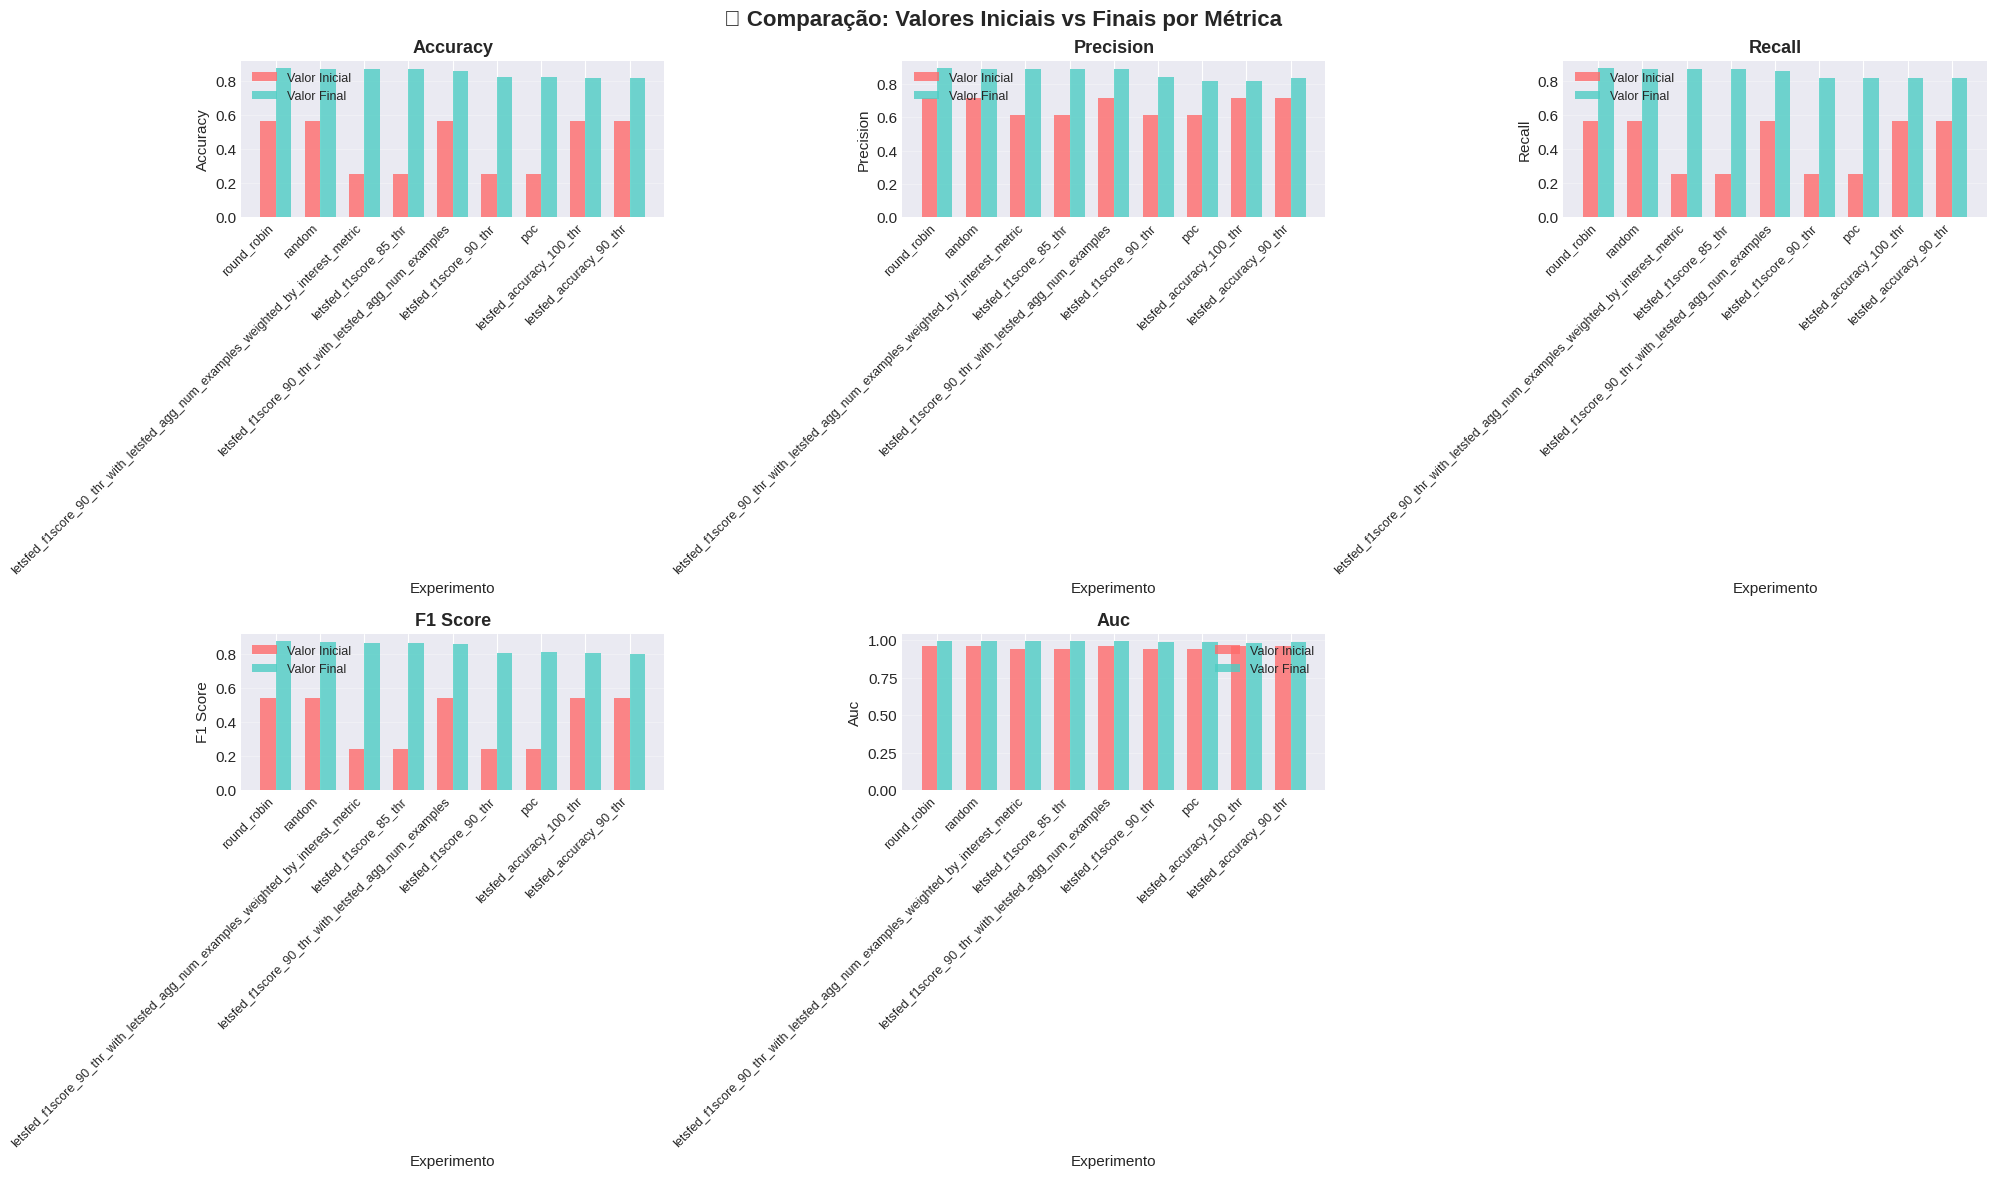


📊 Criando gráfico de melhorias absolutas...
💾 Salvo: topico-5-melhoria-absoluta-por-metrica.png
💾 Salvo: topico-5-melhoria-absoluta-por-metrica.png


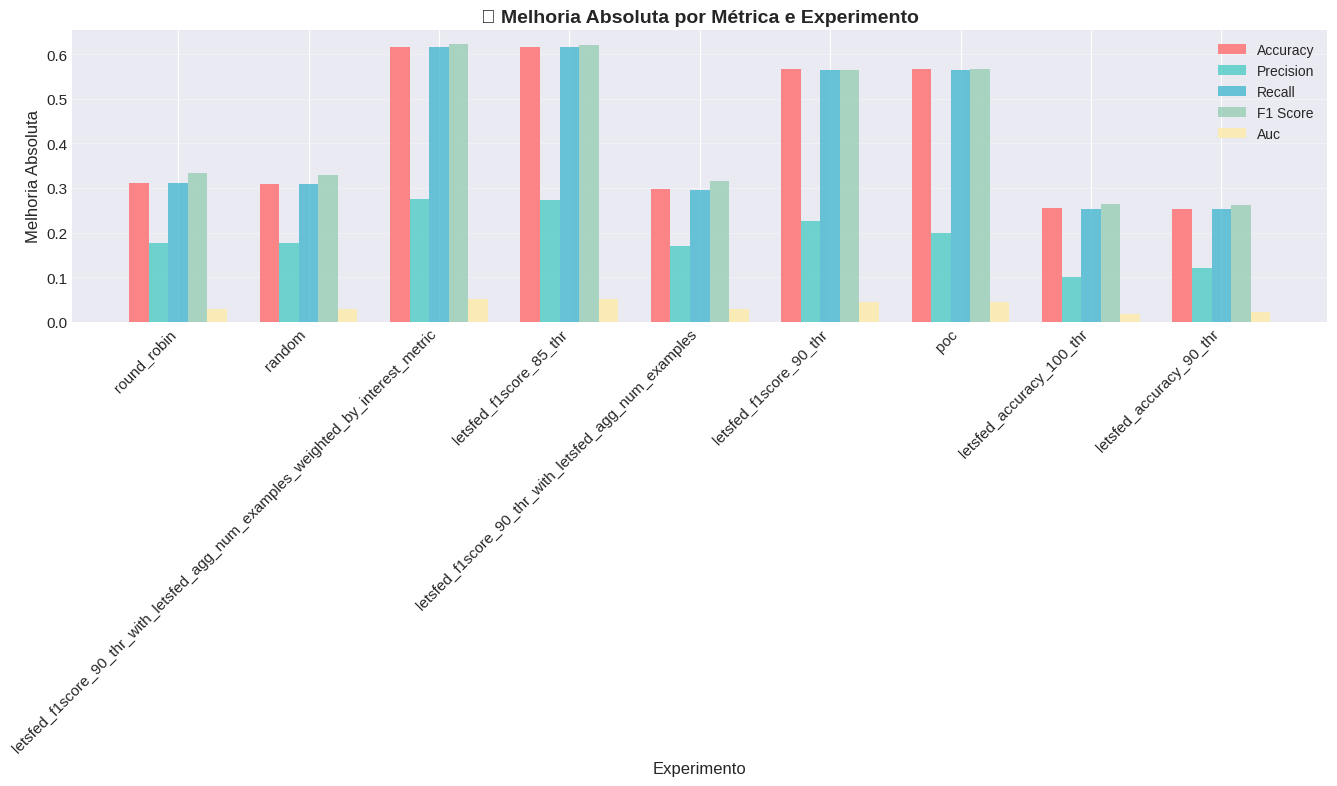


🔥 Criando heatmap de melhorias...
💾 Salvo: topico-5-heatmap-melhorias.png
💾 Salvo: topico-5-heatmap-melhorias.png


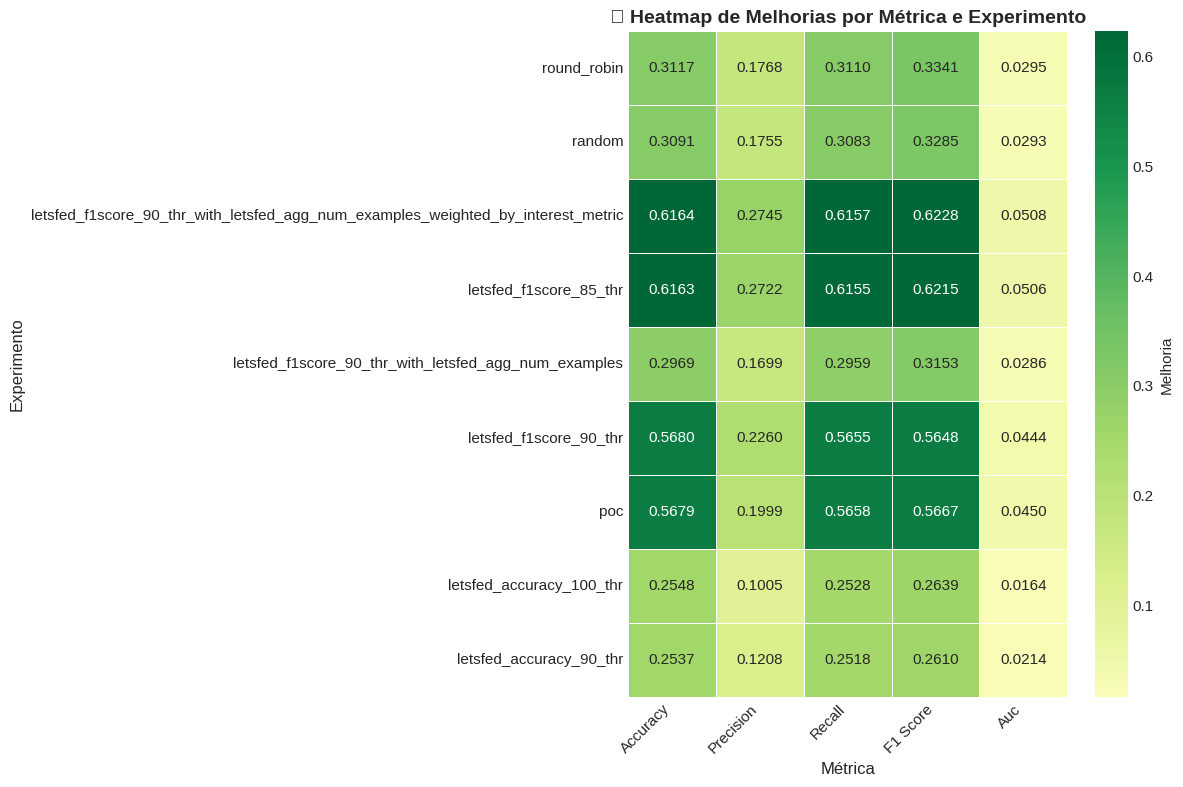


✅ Análise de convergência com múltiplas métricas concluída!


In [ ]:
# Calcular taxa de convergência para múltiplas métricas
print("=" * 80)
print("🚀 TAXA DE CONVERGÊNCIA (Melhoria de Múltiplas Métricas)")
print("=" * 80)

print("\n🔍 Iniciando cálculo de convergência...")
print(f"📊 Total de experimentos a processar: {len(server_df['experiment'].unique())}")

convergence_stats = []

# Métricas a analisar
metrics_to_analyze = ["accuracy", "precision", "recall", "f1_score", "auc"]

for experiment in sorted(server_df["experiment"].unique()):
    data = server_df[server_df["experiment"] == experiment].sort_values("rounds")

    if len(data) < 2:
        print(f"  ⚠️ Experimento {experiment} tem menos de 2 rounds, pulando...")
        continue

    stats = {"experiment": experiment, "num_rounds": len(data)}

    # Calcular melhorias para cada métrica
    for metric in metrics_to_analyze:
        initial_val = data[metric].iloc[0]
        final_val = data[metric].iloc[-1]
        improvement = final_val - initial_val
        avg_improvement_per_round = improvement / len(data)

        stats[f"{metric}_initial"] = initial_val
        stats[f"{metric}_final"] = final_val
        stats[f"{metric}_improvement"] = improvement
        stats[f"{metric}_avg_per_round"] = avg_improvement_per_round

    convergence_stats.append(stats)

print("\n📊 Criando DataFrame de convergência...")
convergence_df = pd.DataFrame(convergence_stats)
convergence_df = convergence_df.sort_values("accuracy_final", ascending=False)

# Exibir tabela resumida (apenas valores iniciais e finais)
display_cols = ["experiment", "num_rounds"] + [
    f"{m}_{t}" for m in metrics_to_analyze for t in ["initial", "final", "improvement"]
]
print("\n📋 Exibindo tabela resumida...")
display(convergence_df[display_cols])

print("\n💾 Salvando tabela de convergência...")
# Salvar tabela completa de convergência
fig, ax = plt.subplots(figsize=(20, len(convergence_df) * 0.7 + 1))
ax.axis("tight")
ax.axis("off")
table_data = convergence_df[display_cols].round(4)
table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1, 2)
# Colorir header
for i in range(len(table_data.columns)):
    table[(0, i)].set_facecolor("#4CAF50")
    table[(0, i)].set_text_props(weight="bold", color="white")
plt.title(
    "Topico 5 - Taxa de Convergência por Experimento (Múltiplas Métricas)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.savefig(
    output_dir / "topico-5-tabela-convergencia-multiplas-metricas.png", dpi=300, bbox_inches="tight"
)
plt.close()
print("💾 Salvo: topico-5-tabela-convergencia-multiplas-metricas.png")

print("\n📊 Criando gráficos de comparação...")
# Plotar comparação de convergência para cada métrica
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(
    "📊 Comparação: Valores Iniciais vs Finais por Métrica", fontsize=16, fontweight="bold"
)

axes = axes.flatten()

for idx, metric in enumerate(metrics_to_analyze):
    print(f"  📈 Plotando métrica: {metric}")
    ax = axes[idx]
    x = np.arange(len(convergence_df))
    width = 0.35

    ax.bar(
        x - width / 2,
        convergence_df[f"{metric}_initial"],
        width,
        label="Valor Inicial",
        alpha=0.8,
        color="#FF6B6B",
    )
    ax.bar(
        x + width / 2,
        convergence_df[f"{metric}_final"],
        width,
        label="Valor Final",
        alpha=0.8,
        color="#4ECDC4",
    )

    ax.set_xlabel("Experimento", fontsize=11)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=11)
    ax.set_title(f"{metric.replace('_', ' ').title()}", fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(convergence_df["experiment"], rotation=45, ha="right", fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

# Remover eixo extra
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig(
    output_dir / "topico-5-comparacao-inicial-final-multiplas-metricas.png",
    dpi=300,
    bbox_inches="tight",
)
print("💾 Salvo: topico-5-comparacao-inicial-final-multiplas-metricas.png")
plt.show()

print("\n📊 Criando gráfico de melhorias absolutas...")
# Plotar gráfico de barras de melhoria absoluta
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(convergence_df))
width = 0.15

colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]

for idx, metric in enumerate(metrics_to_analyze):
    offset = width * (idx - 2)
    ax.bar(
        x + offset,
        convergence_df[f"{metric}_improvement"],
        width,
        label=metric.replace("_", " ").title(),
        alpha=0.8,
        color=colors[idx],
    )

ax.set_xlabel("Experimento", fontsize=12)
ax.set_ylabel("Melhoria Absoluta", fontsize=12)
ax.set_title("📈 Melhoria Absoluta por Métrica e Experimento", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(convergence_df["experiment"], rotation=45, ha="right")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig(output_dir / "topico-5-melhoria-absoluta-por-metrica.png", dpi=300, bbox_inches="tight")
print("💾 Salvo: topico-5-melhoria-absoluta-por-metrica.png")
plt.show()

print("\n🔥 Criando heatmap de melhorias...")
# Criar heatmap de melhorias
fig, ax = plt.subplots(figsize=(12, 8))

# Preparar dados para o heatmap
heatmap_data = convergence_df.set_index("experiment")[
    [f"{m}_improvement" for m in metrics_to_analyze]
]
heatmap_data.columns = [m.replace("_", " ").title() for m in metrics_to_analyze]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="RdYlGn",
    center=0,
    cbar_kws={"label": "Melhoria"},
    linewidths=0.5,
)

plt.title("🔥 Heatmap de Melhorias por Métrica e Experimento", fontsize=14, fontweight="bold")
plt.ylabel("Experimento", fontsize=12)
plt.xlabel("Métrica", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(output_dir / "topico-5-heatmap-melhorias.png", dpi=300, bbox_inches="tight")
print("💾 Salvo: topico-5-heatmap-melhorias.png")
plt.show()

print("\n✅ Análise de convergência com múltiplas métricas concluída!")

## 6️⃣ Análise de Fairness e Participação dos Clientes


In [10]:
# Analisar frequência de seleção de cada cliente
print("=" * 80)
print("👥 ANÁLISE DE SELEÇÃO DE CLIENTES")
print("=" * 80)


def analyze_client_selection(df: pd.DataFrame, experiment_name: str) -> pd.DataFrame:
    """Analisa a frequência de seleção de cada cliente"""
    exp_data = df[df["experiment"] == experiment_name]

    # Contar seleções por cliente
    all_selections = []
    for clients in exp_data["selected_clients"]:
        all_selections.extend(clients)

    if not all_selections:
        return None

    selection_counts = pd.Series(all_selections).value_counts().sort_index()
    total_rounds = len(exp_data)

    return pd.DataFrame(
        {
            "client_id": selection_counts.index,
            "times_selected": selection_counts.values,
            "selection_rate": selection_counts.values / total_rounds,
        }
    )


# Analisar para cada experimento
selection_analysis = {}

for experiment in sorted(server_df["experiment"].unique()):
    analysis = analyze_client_selection(server_df, experiment)
    if analysis is not None:
        selection_analysis[experiment] = analysis

        print(f"\n📌 {experiment.upper()}")
        print("-" * 60)
        display(analysis)

        # Calcular métricas de fairness
        std_selection = analysis["times_selected"].std()
        mean_selection = analysis["times_selected"].mean()
        cv = std_selection / mean_selection if mean_selection > 0 else 0  # Coeficiente de variação

        print("\n📊 Métricas de Fairness:")
        print(f"  - Desvio padrão: {std_selection:.2f}")
        print(f"  - Coeficiente de variação: {cv:.4f} (quanto menor, mais justo)")

👥 ANÁLISE DE SELEÇÃO DE CLIENTES

📌 LETSFED_ACCURACY_100_THR
------------------------------------------------------------


,client_id,times_selected,selection_rate
0,0,21,0.700000
1,1,21,0.700000
2,2,20,0.666667
3,3,15,0.500000
4,4,15,0.500000



📊 Métricas de Fairness:
  - Desvio padrão: 3.13
  - Coeficiente de variação: 0.1701 (quanto menor, mais justo)

📌 LETSFED_ACCURACY_90_THR
------------------------------------------------------------


,client_id,times_selected,selection_rate
0,0,20,0.666667
1,1,20,0.666667
2,2,16,0.533333
3,3,16,0.533333
4,4,20,0.666667



📊 Métricas de Fairness:
  - Desvio padrão: 2.19
  - Coeficiente de variação: 0.1191 (quanto menor, mais justo)

📌 LETSFED_F1SCORE_85_THR
------------------------------------------------------------


...


📊 Métricas de Fairness:
  - Desvio padrão: 14.79
  - Coeficiente de variação: 1.1554 (quanto menor, mais justo)

📌 RANDOM
------------------------------------------------------------


,client_id,times_selected,selection_rate
0,0,16,0.533333
1,1,21,0.700000
2,2,19,0.633333
3,3,18,0.600000
4,4,18,0.600000



📊 Métricas de Fairness:
  - Desvio padrão: 1.82
  - Coeficiente de variação: 0.0987 (quanto menor, mais justo)

📌 ROUND_ROBIN
------------------------------------------------------------


,client_id,times_selected,selection_rate
0,0,19,0.633333
1,1,19,0.633333
2,2,18,0.600000
3,3,18,0.600000
4,4,18,0.600000



📊 Métricas de Fairness:
  - Desvio padrão: 0.55
  - Coeficiente de variação: 0.0298 (quanto menor, mais justo)


💾 Salvo: topico-6-distribuicao-selecoes-clientes.png


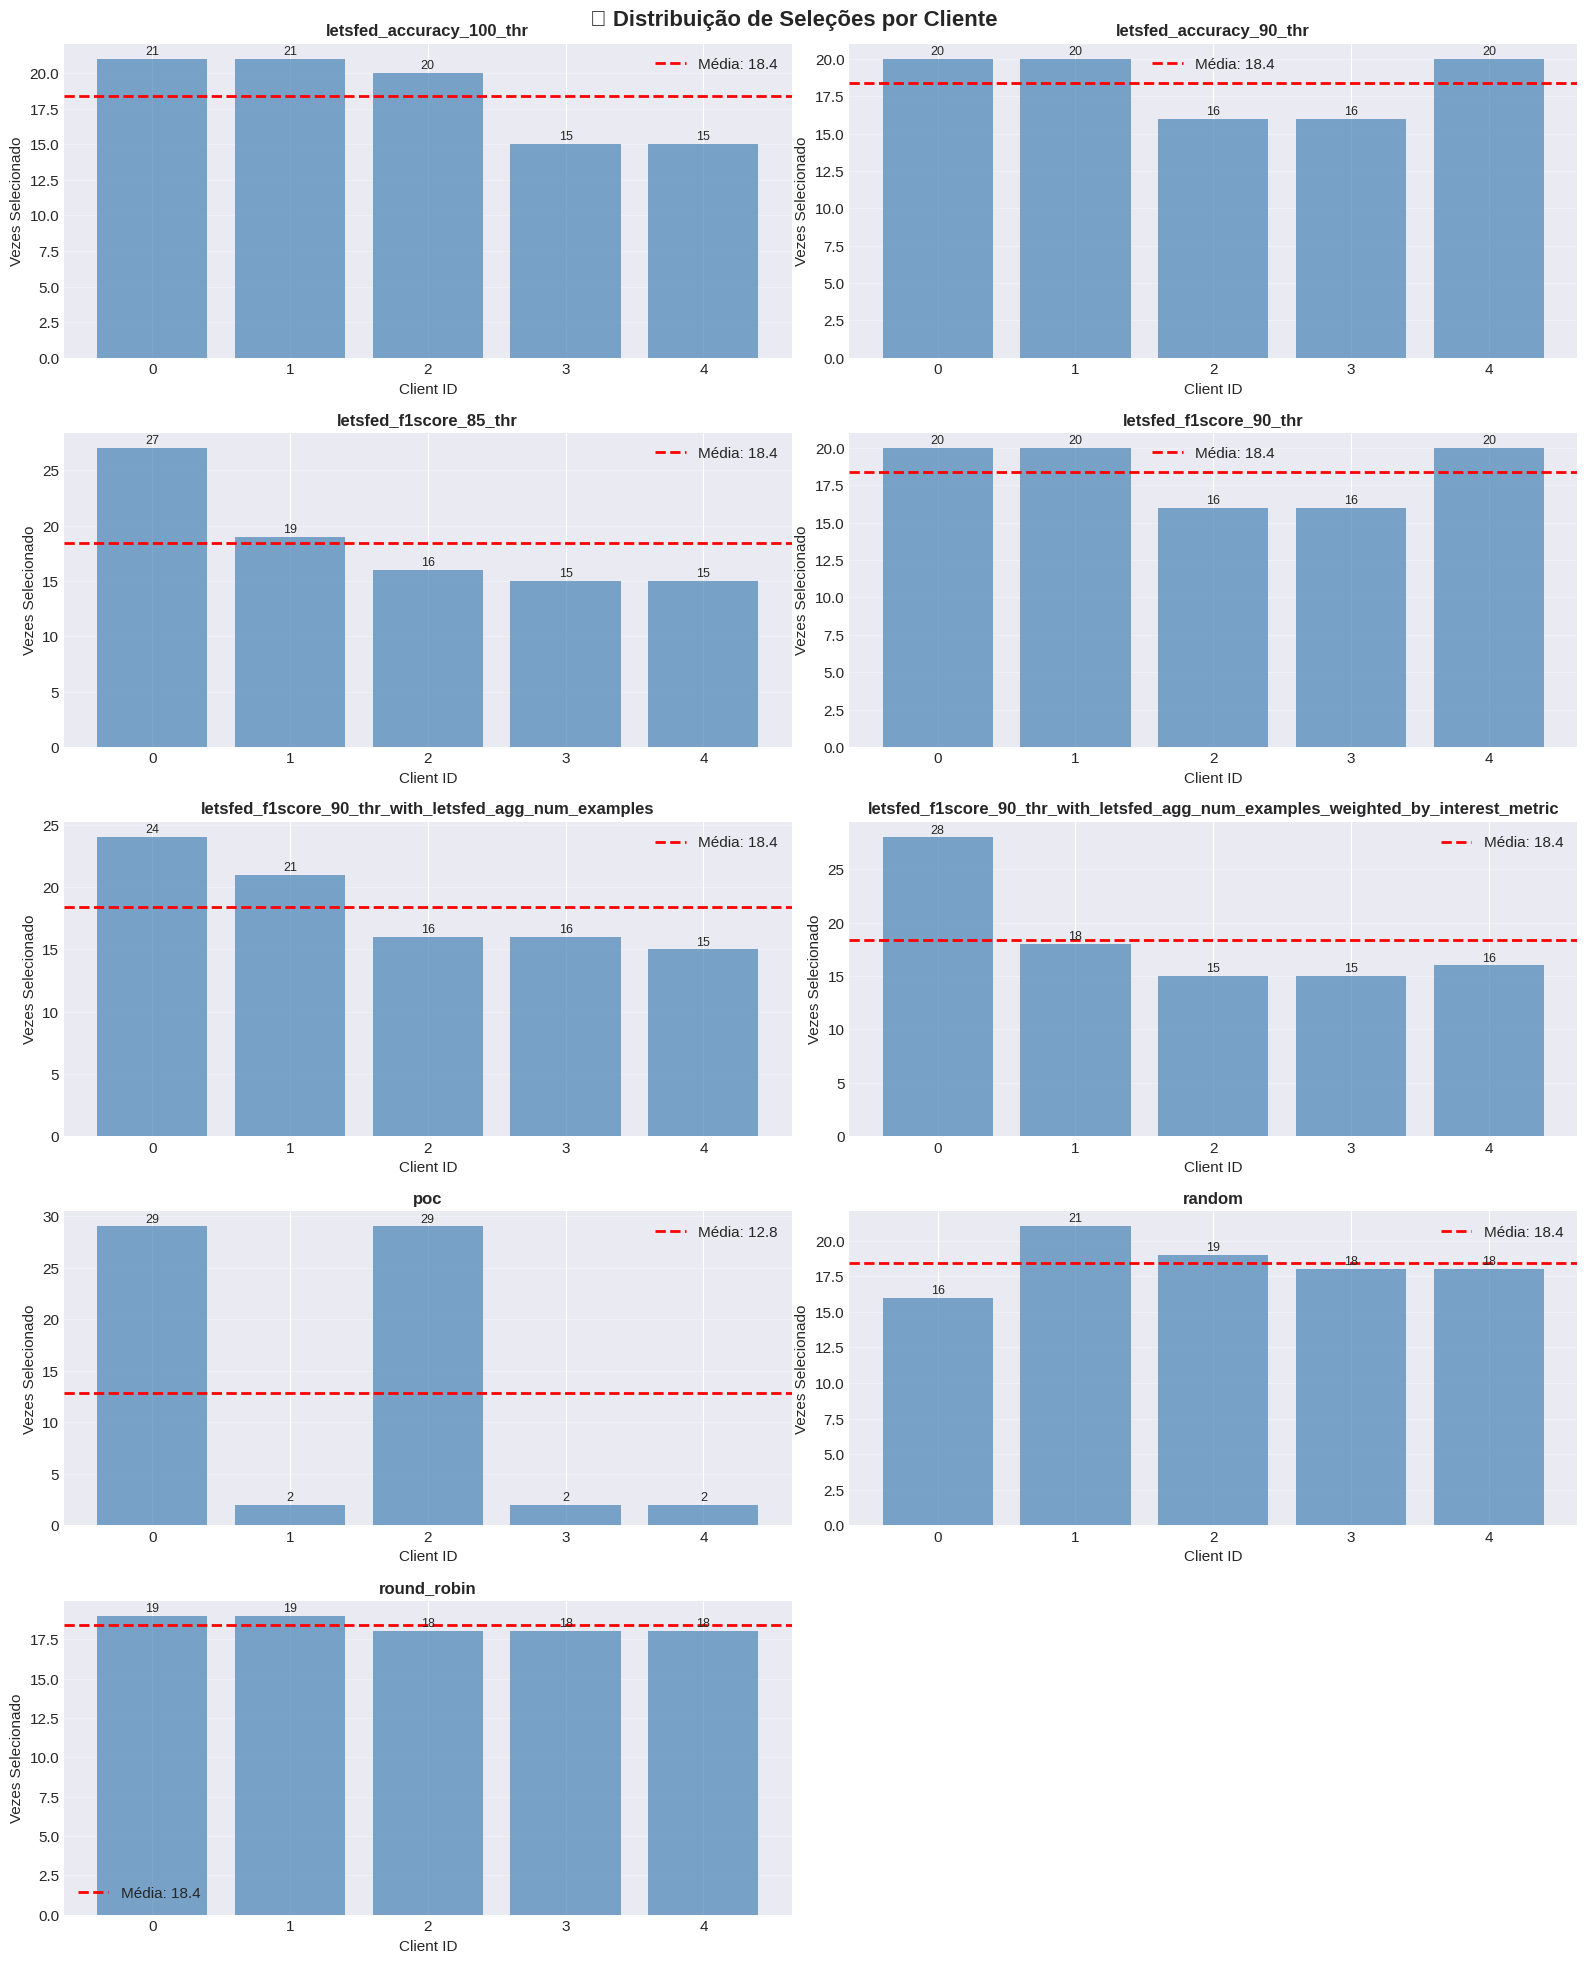

In [ ]:
# Visualizar distribuição de seleções
num_experiments = len(selection_analysis)

# Criar subplots adequadamente baseado no número de experimentos
if num_experiments == 1:
    fig, ax = plt.subplots(figsize=(10, 6))
    axes = [ax]
else:
    nrows = (num_experiments + 1) // 2
    fig, axes_array = plt.subplots(nrows, 2, figsize=(16, 4 * nrows))
    axes = axes_array.flatten()

fig.suptitle("👥 Distribuição de Seleções por Cliente", fontsize=16, fontweight="bold")

for idx, (experiment, data) in enumerate(sorted(selection_analysis.items())):
    ax = axes[idx]

    ax.bar(data["client_id"], data["times_selected"], color="steelblue", alpha=0.7)
    ax.axhline(
        y=data["times_selected"].mean(),
        color="red",
        linestyle="--",
        label=f"Média: {data['times_selected'].mean():.1f}",
        linewidth=2,
    )

    ax.set_xlabel("Client ID", fontsize=11)
    ax.set_ylabel("Vezes Selecionado", fontsize=11)
    ax.set_title(f"{experiment}", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    # Adicionar valores nas barras
    for i, v in enumerate(data["times_selected"]):
        ax.text(data["client_id"].iloc[i], v + 0.1, str(v), ha="center", va="bottom", fontsize=9)

# Remover eixos extras se houver (apenas se temos mais de 1 experimento)
if num_experiments > 1:
    for idx in range(len(selection_analysis), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(
    output_dir / "topico-6-distribuicao-selecoes-clientes.png", dpi=300, bbox_inches="tight"
)
print("💾 Salvo: topico-6-distribuicao-selecoes-clientes.png")
plt.show()


⚖️ COMPARAÇÃO DE FAIRNESS ENTRE EXPERIMENTOS

(Coeficiente de Variação e Gini: quanto menor, mais justo)



,experiment,mean_selections,std_selections,cv,gini_coefficient,min_selections,max_selections
8,round_robin,18.4,0.547723,0.029768,0.013043,18,19
7,random,18.4,1.816590,0.098728,0.047826,16,21
3,letsfed_f1score_90_thr,18.4,2.190890,0.119070,0.052174,16,20
1,letsfed_accuracy_90_thr,18.4,2.190890,0.119070,0.052174,16,20
0,letsfed_accuracy_100_thr,18.4,3.130495,0.170136,0.078261,15,21
4,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,18.4,3.911521,0.212583,0.100000,15,24
2,letsfed_f1score_85_thr,18.4,5.079370,0.276053,0.121739,15,27
5,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,18.4,5.504544,0.299160,0.126087,15,28
6,poc,12.8,14.788509,1.155352,0.506250,2,29


💾 Salvo: topico-6-tabela-fairness.png
💾 Salvo: topico-6-comparacao-fairness-cv-gini.png
💾 Salvo: topico-6-comparacao-fairness-cv-gini.png


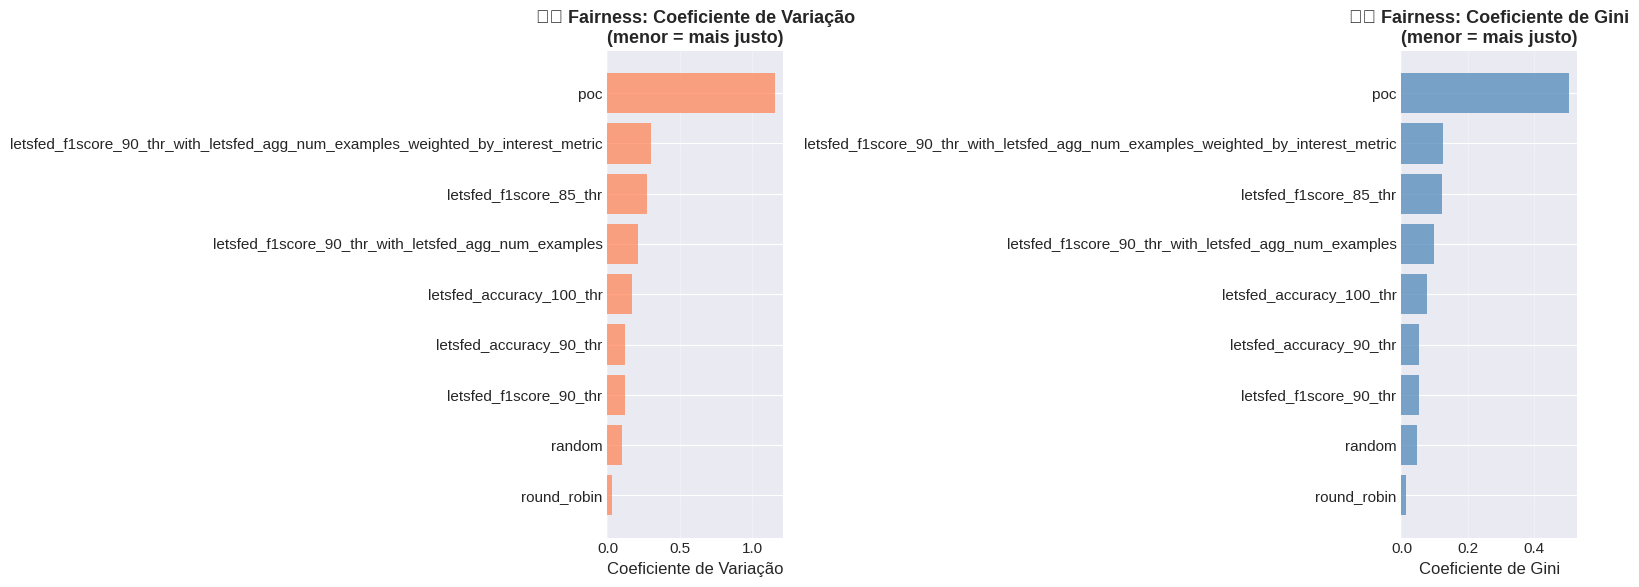

In [ ]:
# Calcular coeficiente de Gini
def calculate_gini_coefficient(x: np.ndarray) -> float:
    """Calcula o coeficiente de Gini (0 = perfeitamente igual, 1 = perfeitamente desigual)"""
    sorted_x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(sorted_x)
    return (2 * np.sum((np.arange(1, n + 1)) * sorted_x)) / (n * cumsum[-1]) - (n + 1) / n


# Comparar fairness entre experimentos
fairness_comparison = []

for experiment, data in selection_analysis.items():
    std_selection = data["times_selected"].std()
    mean_selection = data["times_selected"].mean()
    cv = std_selection / mean_selection if mean_selection > 0 else 0
    gini = calculate_gini_coefficient(data["times_selected"].values)

    fairness_comparison.append(
        {
            "experiment": experiment,
            "mean_selections": mean_selection,
            "std_selections": std_selection,
            "cv": cv,
            "gini_coefficient": gini,
            "min_selections": data["times_selected"].min(),
            "max_selections": data["times_selected"].max(),
        }
    )

fairness_df = pd.DataFrame(fairness_comparison).sort_values("cv")

print("\n" + "=" * 80)
print("⚖️ COMPARAÇÃO DE FAIRNESS ENTRE EXPERIMENTOS")
print("=" * 80)
print("\n(Coeficiente de Variação e Gini: quanto menor, mais justo)\n")
display(fairness_df)

# Salvar tabela de fairness
fig, ax = plt.subplots(figsize=(14, len(fairness_df) * 0.5 + 1))
ax.axis("tight")
ax.axis("off")
table = ax.table(
    cellText=fairness_df.round(4).values,
    colLabels=fairness_df.columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
plt.title(
    "Topico 6 - Comparação de Fairness entre Experimentos", fontsize=14, fontweight="bold", pad=20
)
plt.savefig(output_dir / "topico-6-tabela-fairness.png", dpi=300, bbox_inches="tight")
plt.close()
print("💾 Salvo: topico-6-tabela-fairness.png")

# Plotar comparação de fairness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# CV
ax1.barh(fairness_df["experiment"], fairness_df["cv"], color="coral", alpha=0.7)
ax1.set_xlabel("Coeficiente de Variação", fontsize=12)
ax1.set_title(
    "⚖️ Fairness: Coeficiente de Variação\n(menor = mais justo)", fontsize=13, fontweight="bold"
)
ax1.grid(True, alpha=0.3, axis="x")

# Gini
ax2.barh(fairness_df["experiment"], fairness_df["gini_coefficient"], color="steelblue", alpha=0.7)
ax2.set_xlabel("Coeficiente de Gini", fontsize=12)
ax2.set_title(
    "⚖️ Fairness: Coeficiente de Gini\n(menor = mais justo)", fontsize=13, fontweight="bold"
)
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(output_dir / "topico-6-comparacao-fairness-cv-gini.png", dpi=300, bbox_inches="tight")
print("💾 Salvo: topico-6-comparacao-fairness-cv-gini.png")
plt.show()

## 7️⃣ Análise Detalhada dos Clientes


In [13]:
if client_df is not None:
    print("=" * 80)
    print("👤 ANÁLISE DE PERFORMANCE DOS CLIENTES")
    print("=" * 80)

    # Métricas de teste por cliente
    client_metrics = ["eval_test_accuracy", "eval_test_f1_score", "eval_test_loss"]

    for experiment in sorted(client_df["experiment"].unique())[
        :3
    ]:  # Limitar para não ficar muito extenso
        print(f"\n📌 EXPERIMENTO: {experiment.upper()}")
        print("-" * 60)

        exp_data = client_df[client_df["experiment"] == experiment]

        # Performance final de cada cliente
        final_performance = exp_data.groupby("cid")[client_metrics].last()
        final_performance = final_performance.sort_values("eval_test_accuracy", ascending=False)

        print("\n📊 Performance Final de Cada Cliente (últimas métricas):")
        display(final_performance)

        # Estatísticas de participação
        participation_stats = (
            exp_data.groupby("cid")
            .agg({"selected": "sum", "participating_state": "count", "eval_test_accuracy": "mean"})
            .rename(
                columns={
                    "selected": "times_selected",
                    "participating_state": "total_rounds",
                    "eval_test_accuracy": "avg_test_accuracy",
                }
            )
        )
        participation_stats["selection_rate"] = (
            participation_stats["times_selected"] / participation_stats["total_rounds"]
        )

        print("\n📊 Estatísticas de Participação:")
        display(participation_stats)
else:
    print("⚠️ Dados de cliente não disponíveis para análise detalhada")

👤 ANÁLISE DE PERFORMANCE DOS CLIENTES

📌 EXPERIMENTO: LETSFED_ACCURACY_100_THR
------------------------------------------------------------

📊 Performance Final de Cada Cliente (últimas métricas):


,eval_test_accuracy,eval_test_f1_score,eval_test_loss
cid,,,
4,0.8785,0.876890,0.350140
0,0.8510,0.851126,0.521655
1,0.8335,0.831019,0.535467
3,0.8115,0.812013,0.637894
2,0.7165,0.653157,3.964607



📊 Estatísticas de Participação:


,times_selected,total_rounds,avg_test_accuracy,selection_rate
cid,,,,
0,21,21,0.830857,1.0
1,21,21,0.829381,1.0
2,20,20,0.712625,1.0
3,15,15,0.767033,1.0
4,15,15,0.846533,1.0



📌 EXPERIMENTO: LETSFED_ACCURACY_90_THR
------------------------------------------------------------

📊 Performance Final de Cada Cliente (últimas métricas):


...

,times_selected,total_rounds,avg_test_accuracy,selection_rate
cid,,,,
0,20,20,0.829850,1.0
1,20,20,0.829175,1.0
2,16,16,0.724906,1.0
3,16,16,0.759625,1.0
4,20,20,0.845500,1.0



📌 EXPERIMENTO: LETSFED_AGG_NUM_EXAMPLES_WEIGHTED_BY_INTEREST_METRIC
------------------------------------------------------------

📊 Performance Final de Cada Cliente (últimas métricas):


,eval_test_accuracy,eval_test_f1_score,eval_test_loss
cid,,,
4,0.8930,0.892852,0.291260
0,0.8910,0.890745,0.327951
1,0.8860,0.886694,0.330129
2,0.8455,0.836496,0.403151
3,0.8335,0.824509,0.430375



📊 Estatísticas de Participação:


,times_selected,total_rounds,avg_test_accuracy,selection_rate
cid,,,,
0,28,28,0.844036,1.0
1,18,18,0.830472,1.0
2,15,15,0.794300,1.0
3,15,15,0.798367,1.0
4,16,16,0.845969,1.0


💾 Salvo: topico-7-evolucao-metricas-clientes-letsfed_accuracy_100_thr.png


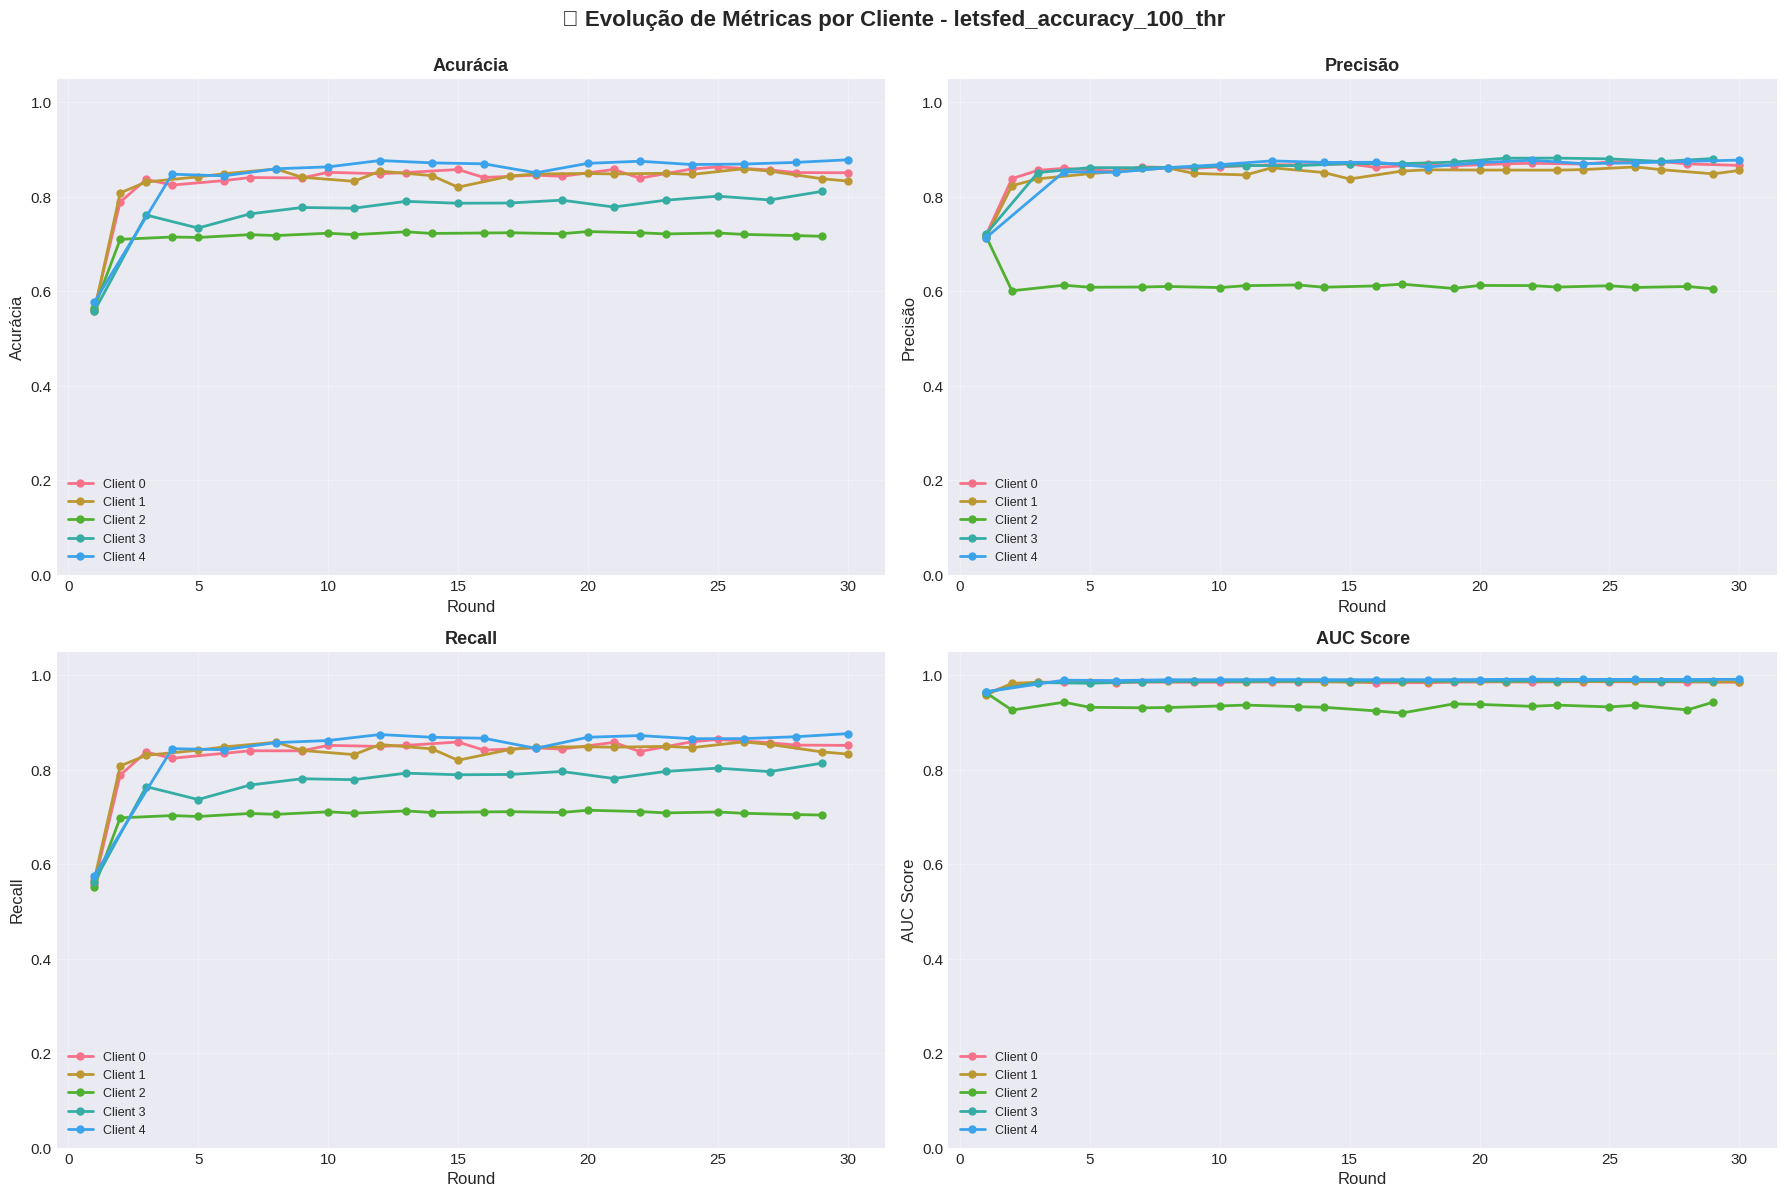

💾 Salvo: topico-7-evolucao-metricas-clientes-letsfed_accuracy_90_thr.png


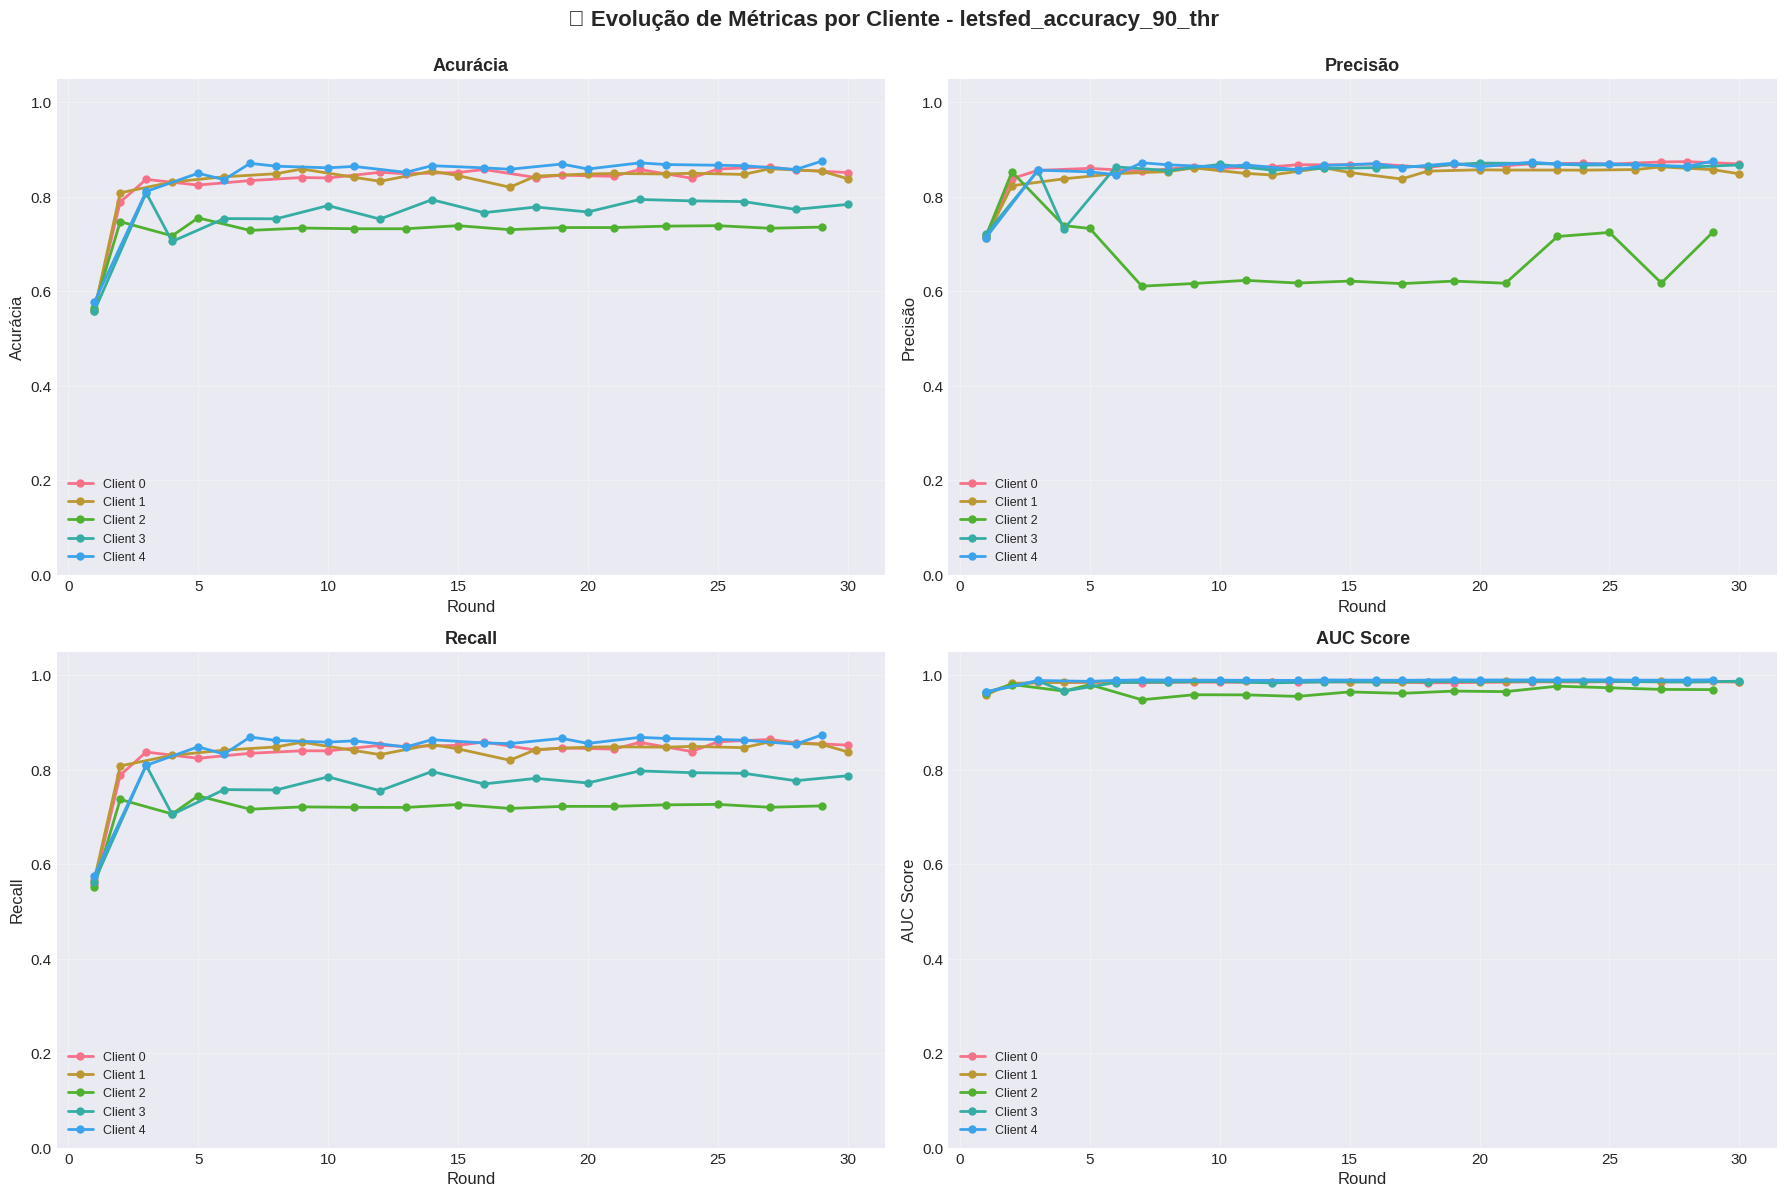

💾 Salvo: topico-7-evolucao-metricas-clientes-letsfed_agg_num_examples_weighted_by_interest_metric.png


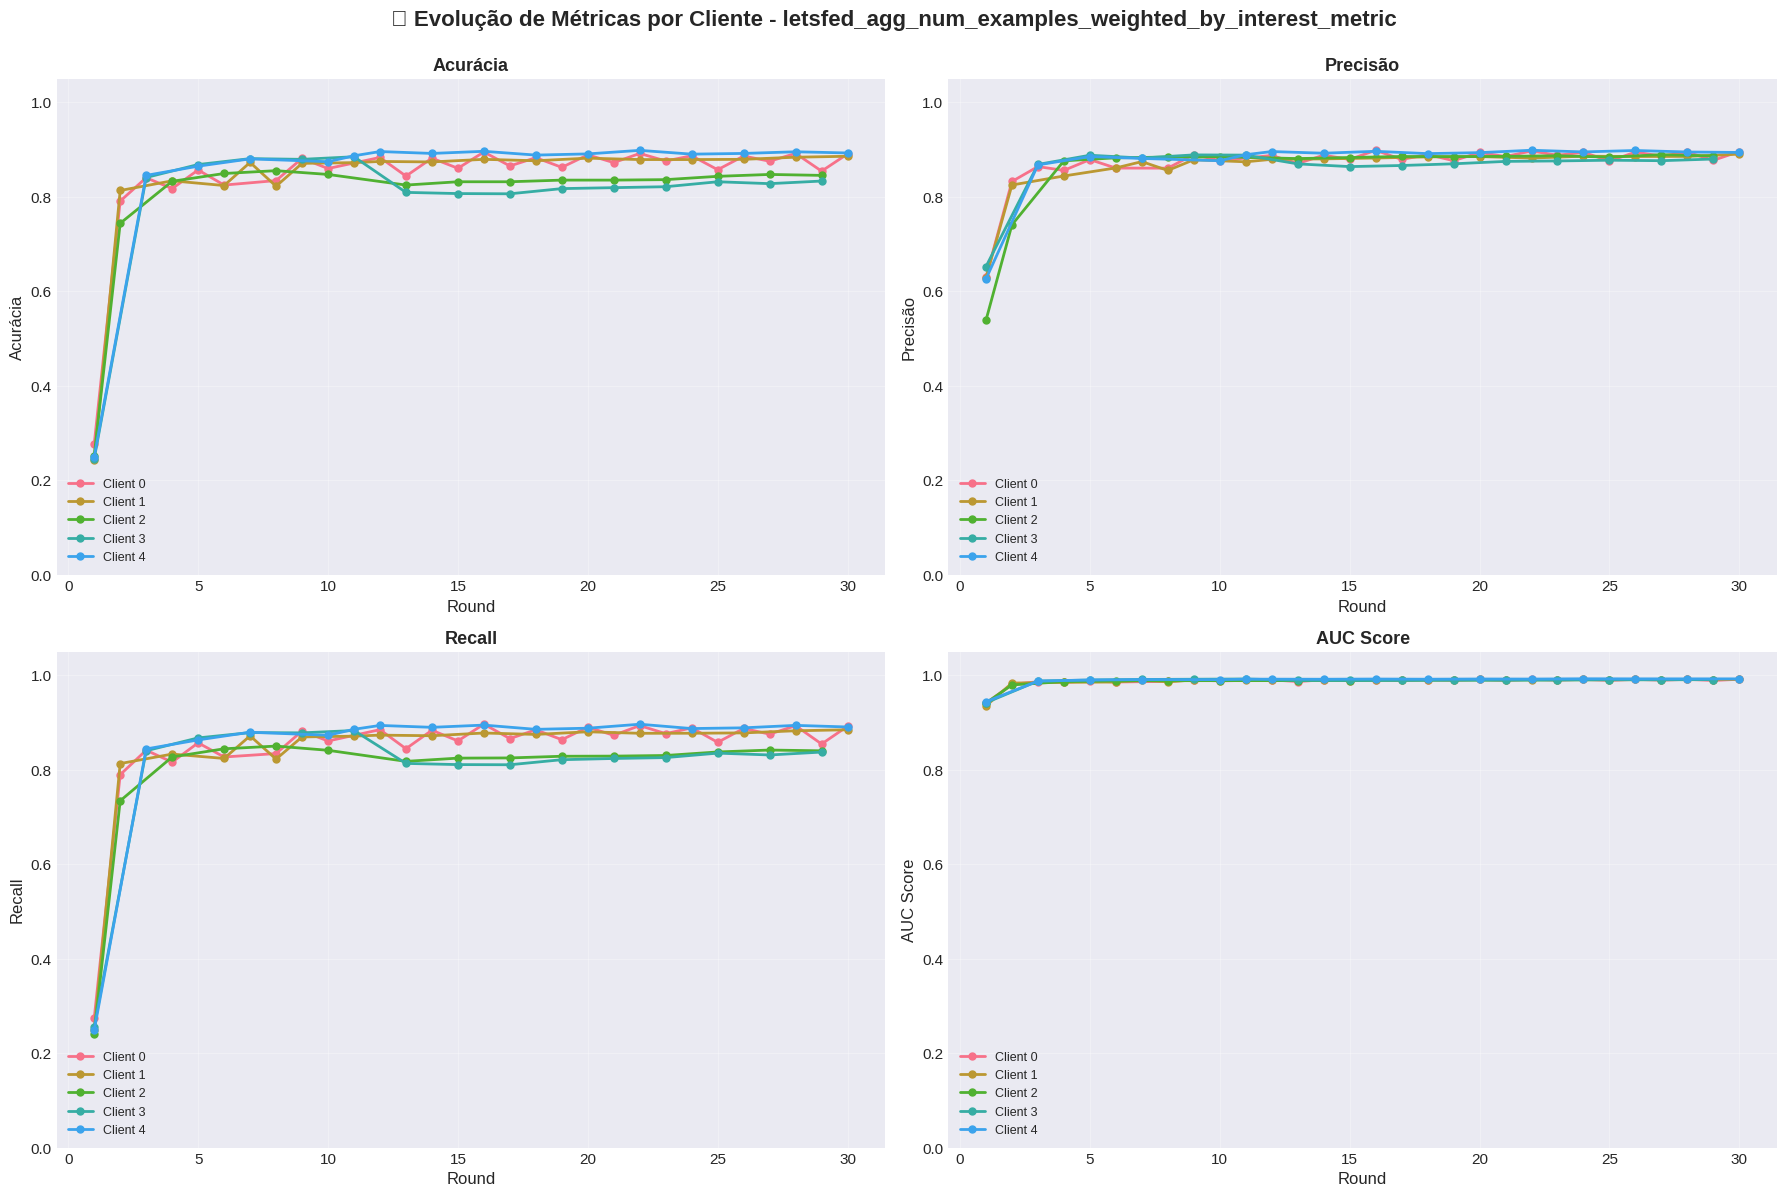

💾 Salvo: topico-7-evolucao-metricas-clientes-letsfed_f1score_85_thr.png


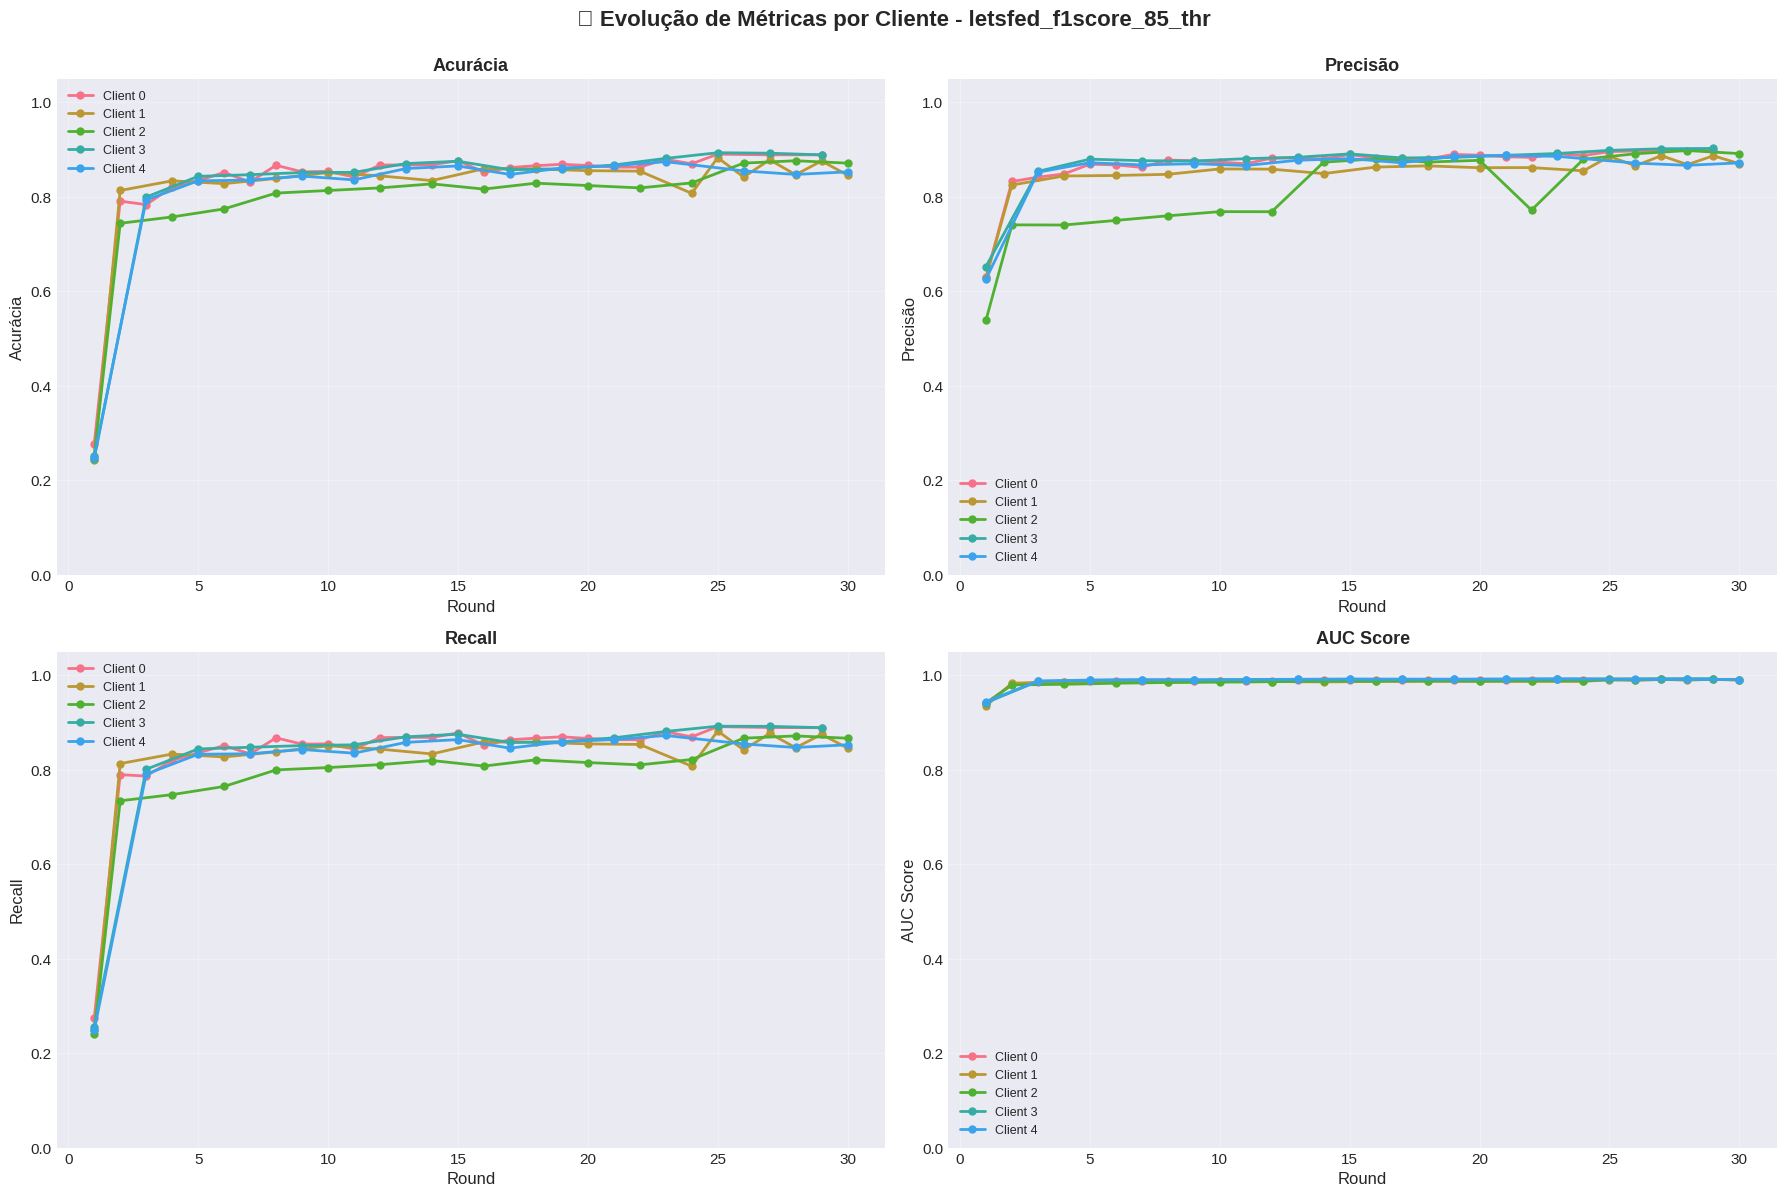

💾 Salvo: topico-7-evolucao-metricas-clientes-letsfed_f1score_90_thr.png


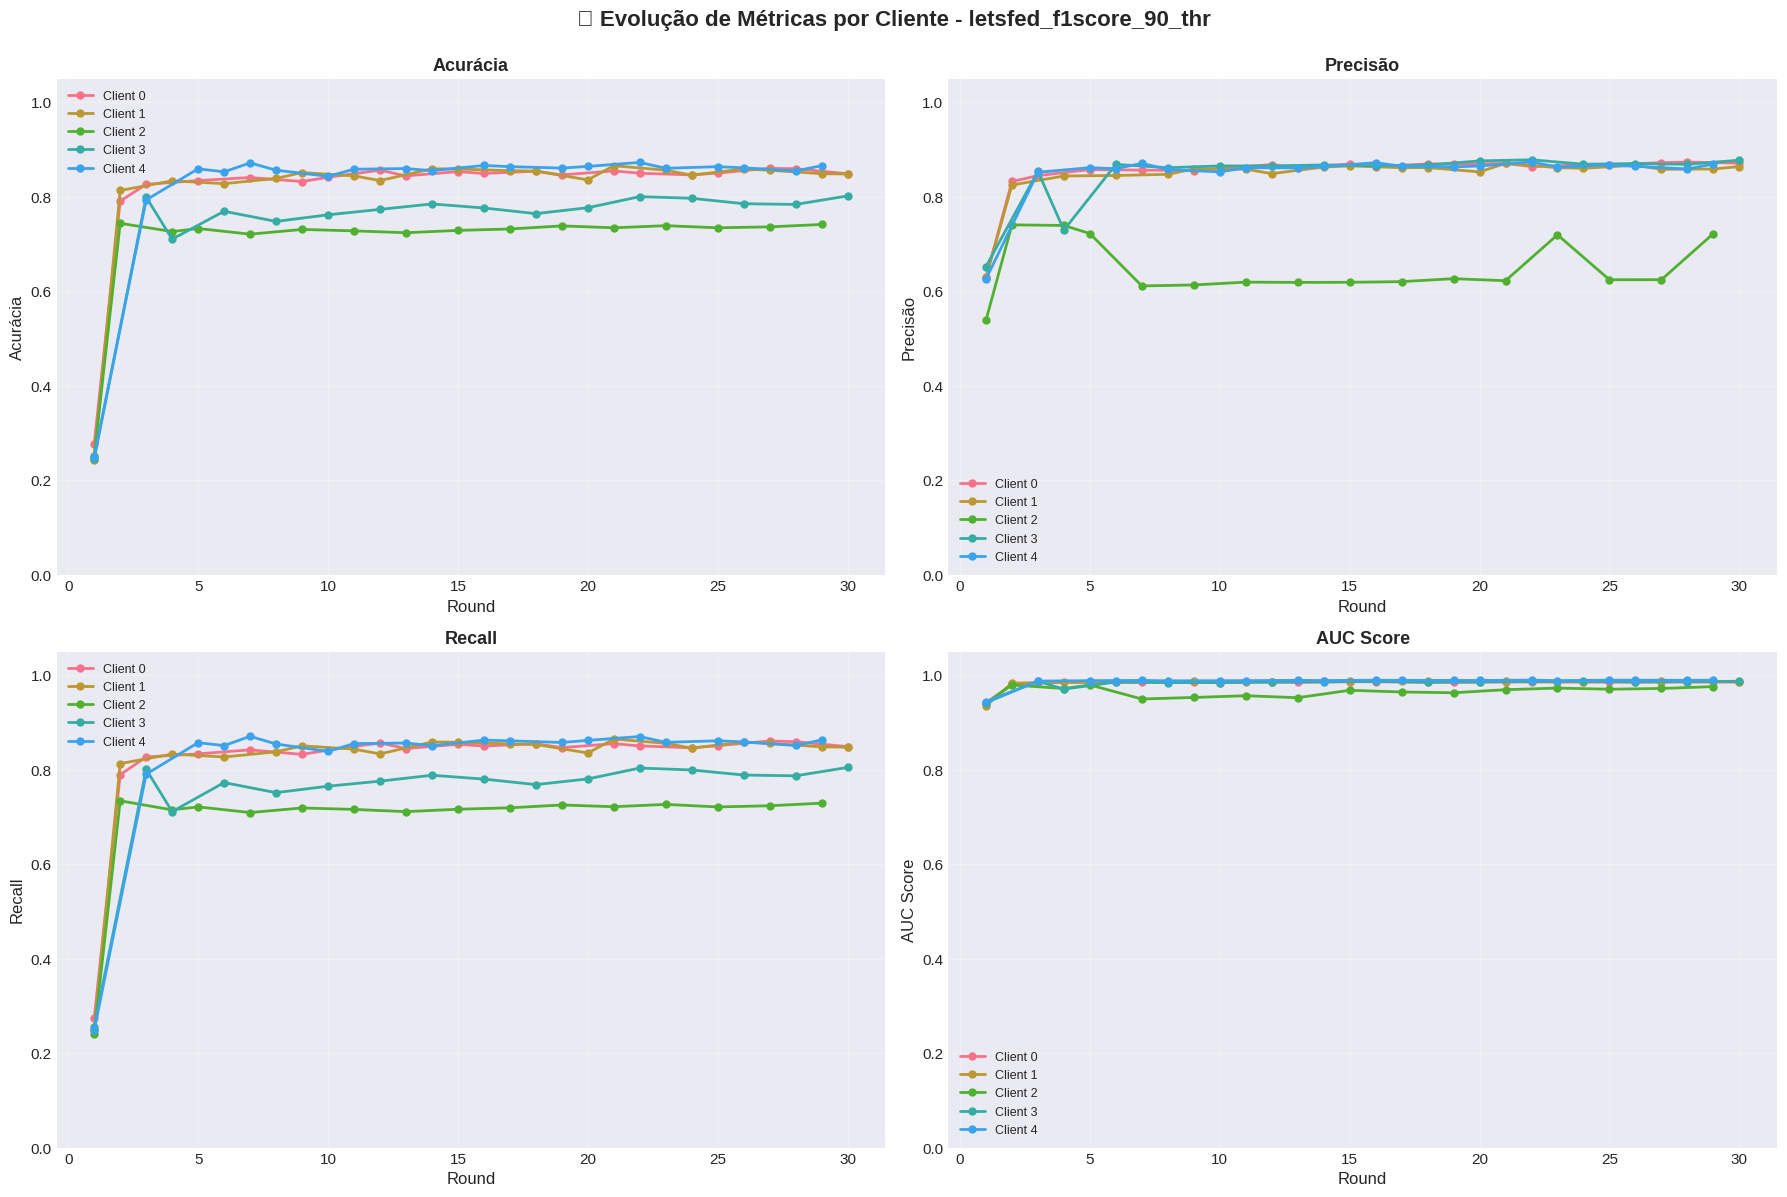

💾 Salvo: topico-7-evolucao-metricas-clientes-letsfed_f1score_90_thr_with_letsfed_agg_num_examples.png


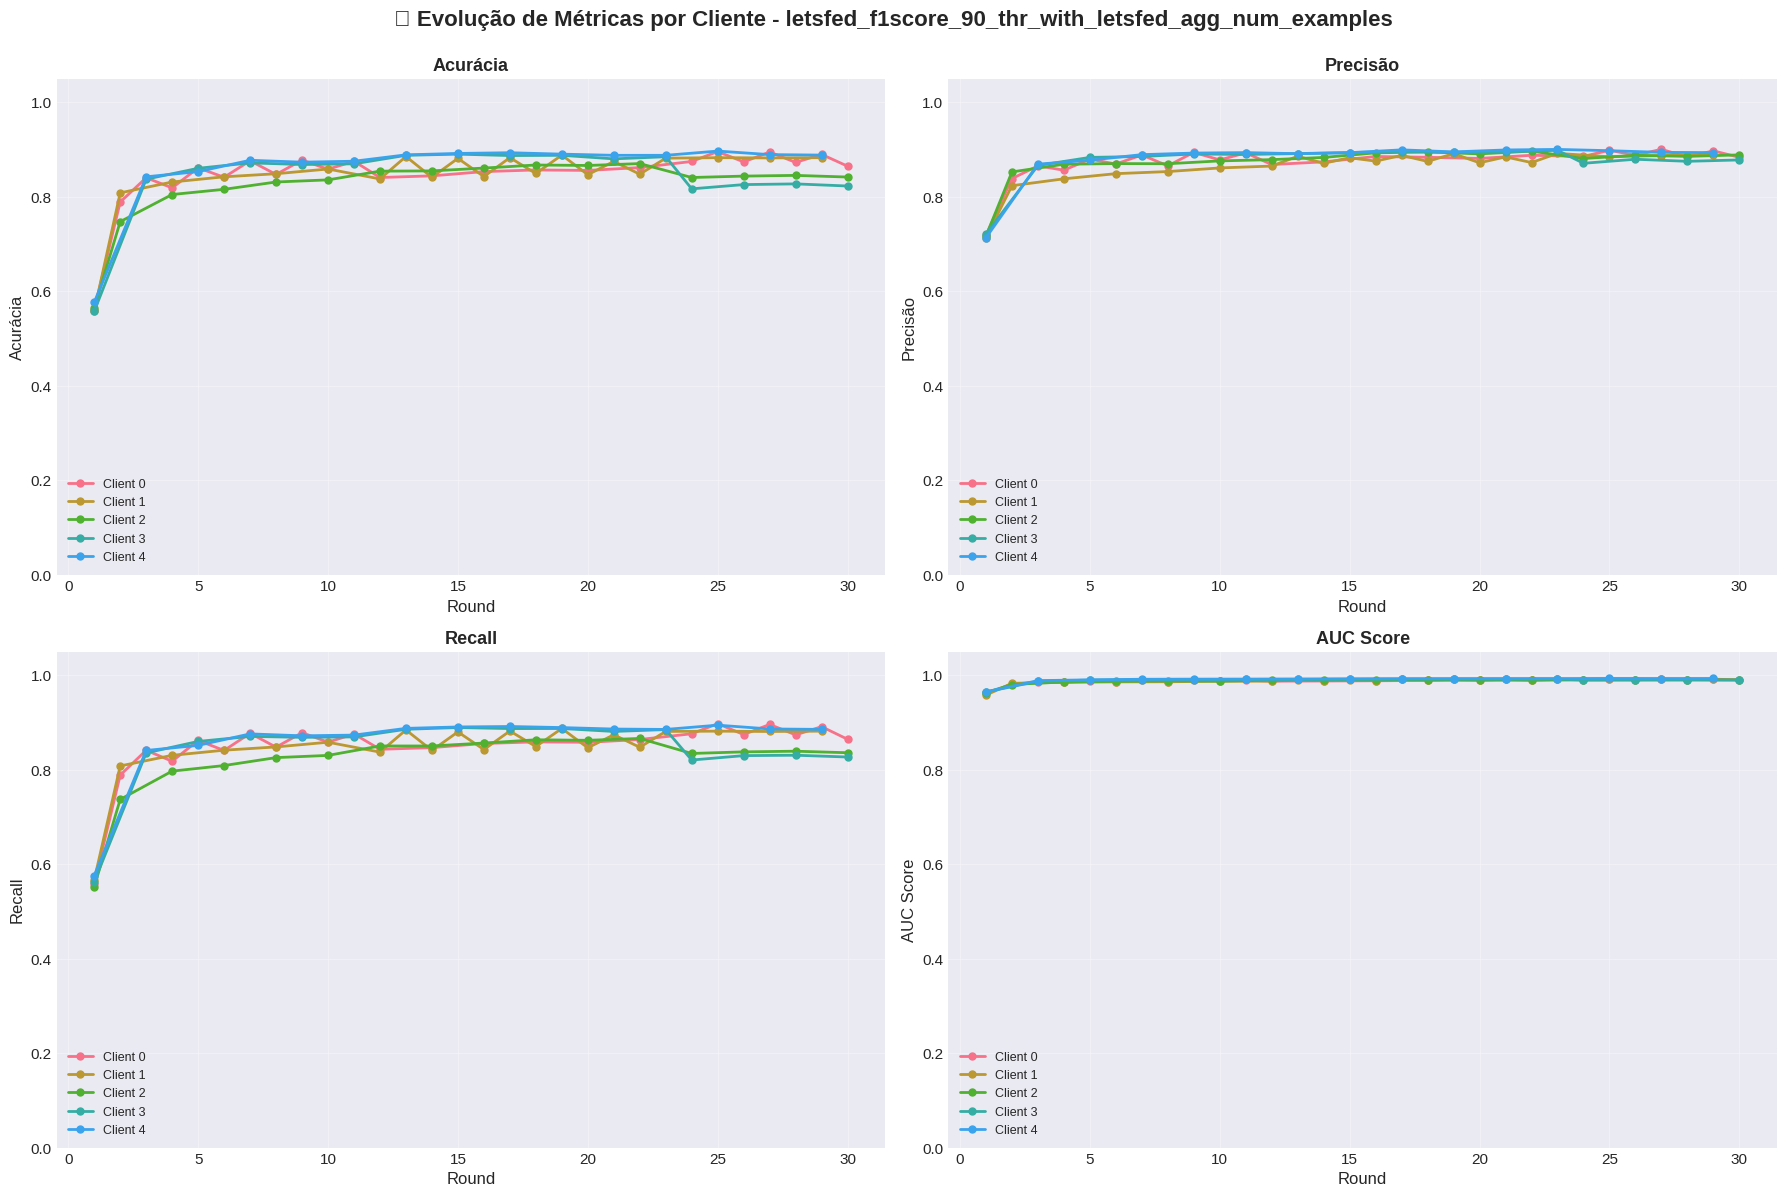

💾 Salvo: topico-7-evolucao-metricas-clientes-poc.png


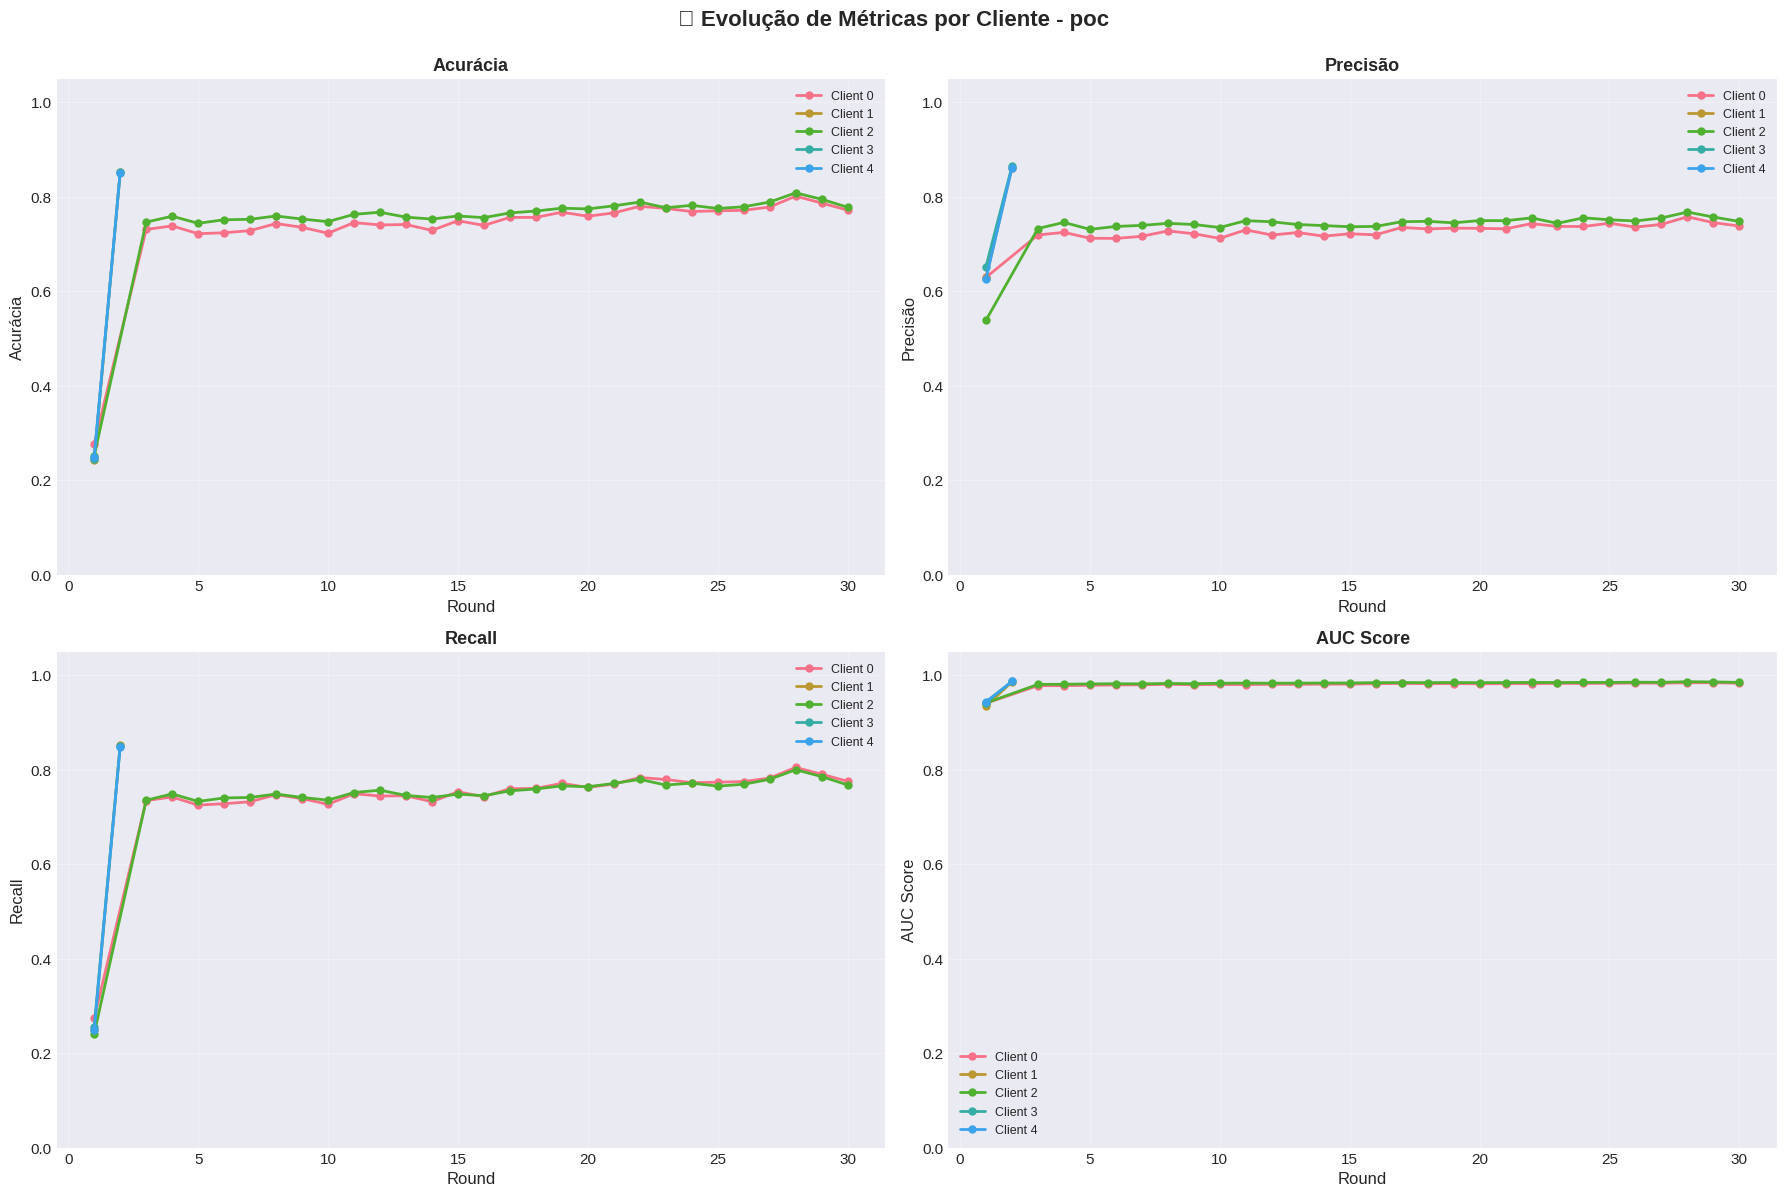

💾 Salvo: topico-7-evolucao-metricas-clientes-random.png


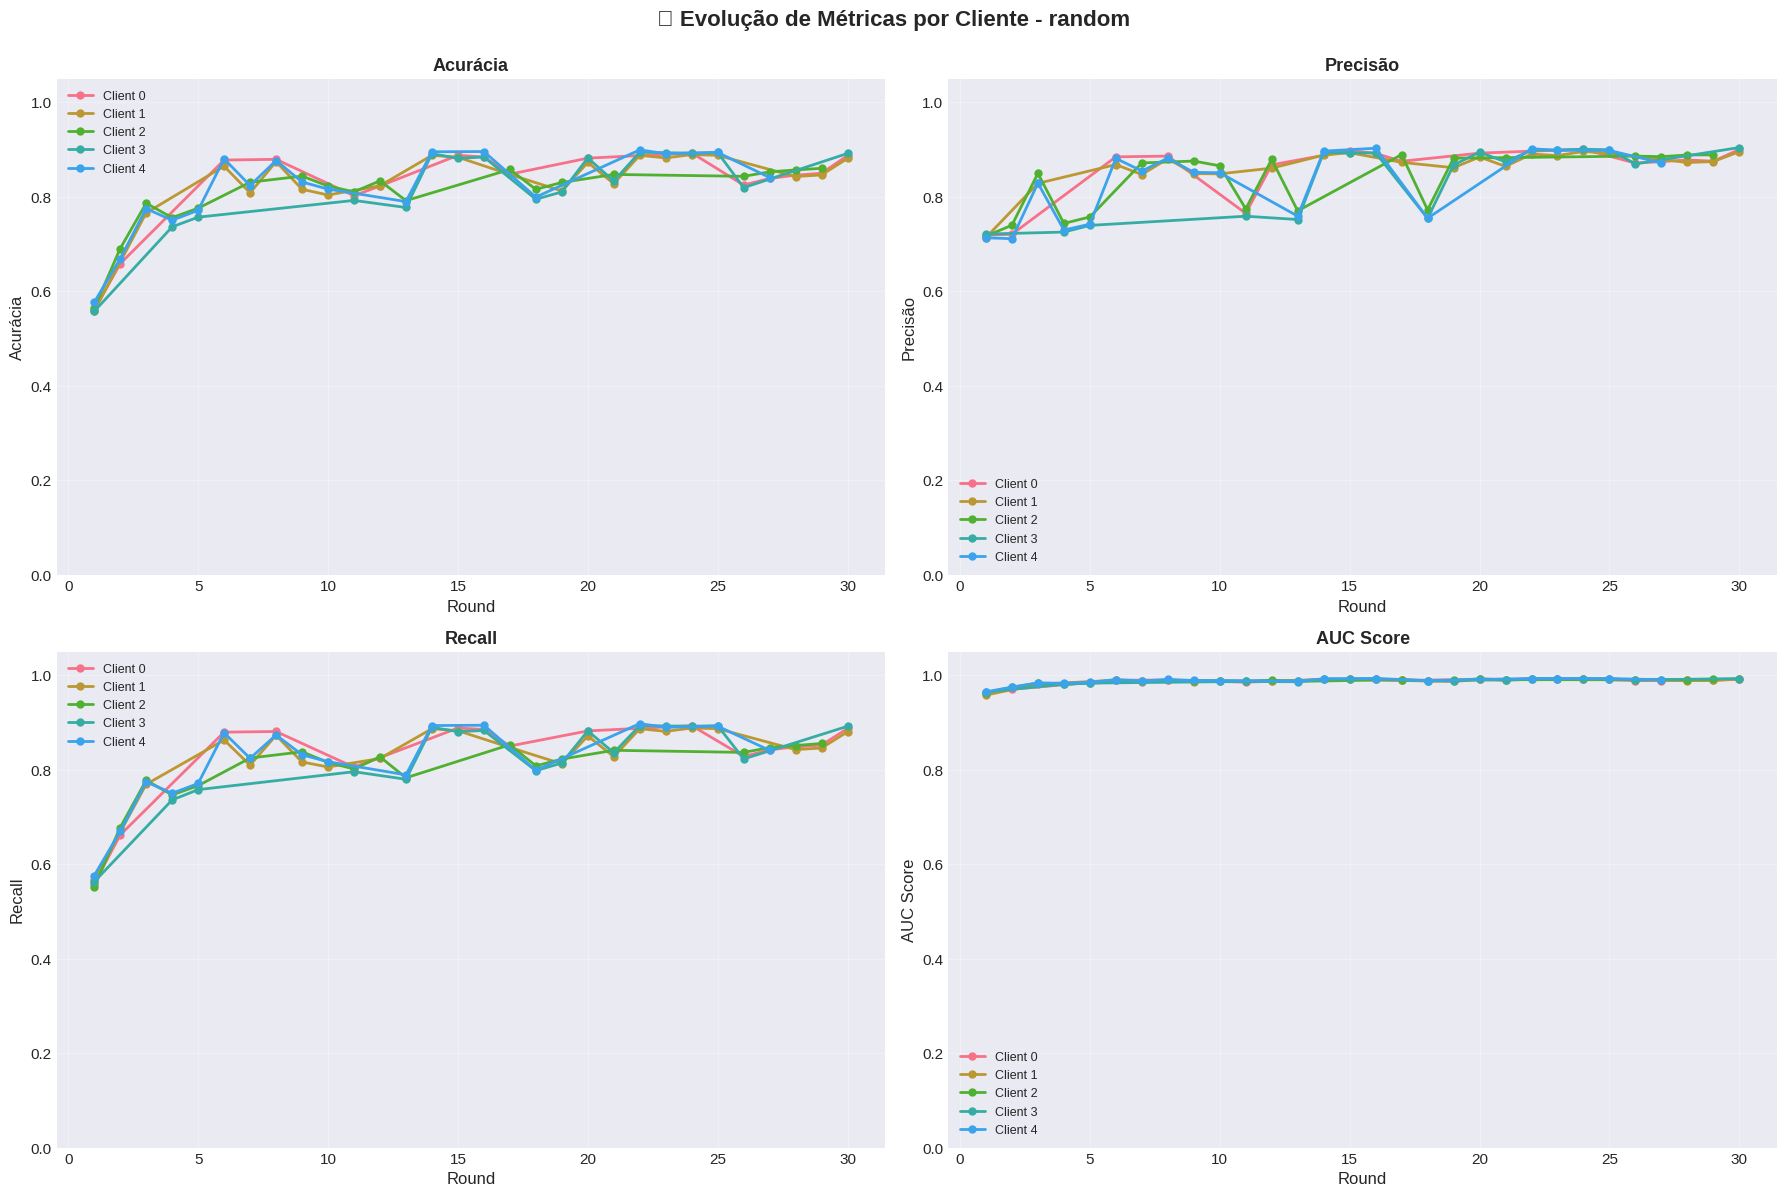

💾 Salvo: topico-7-evolucao-metricas-clientes-round_robin.png


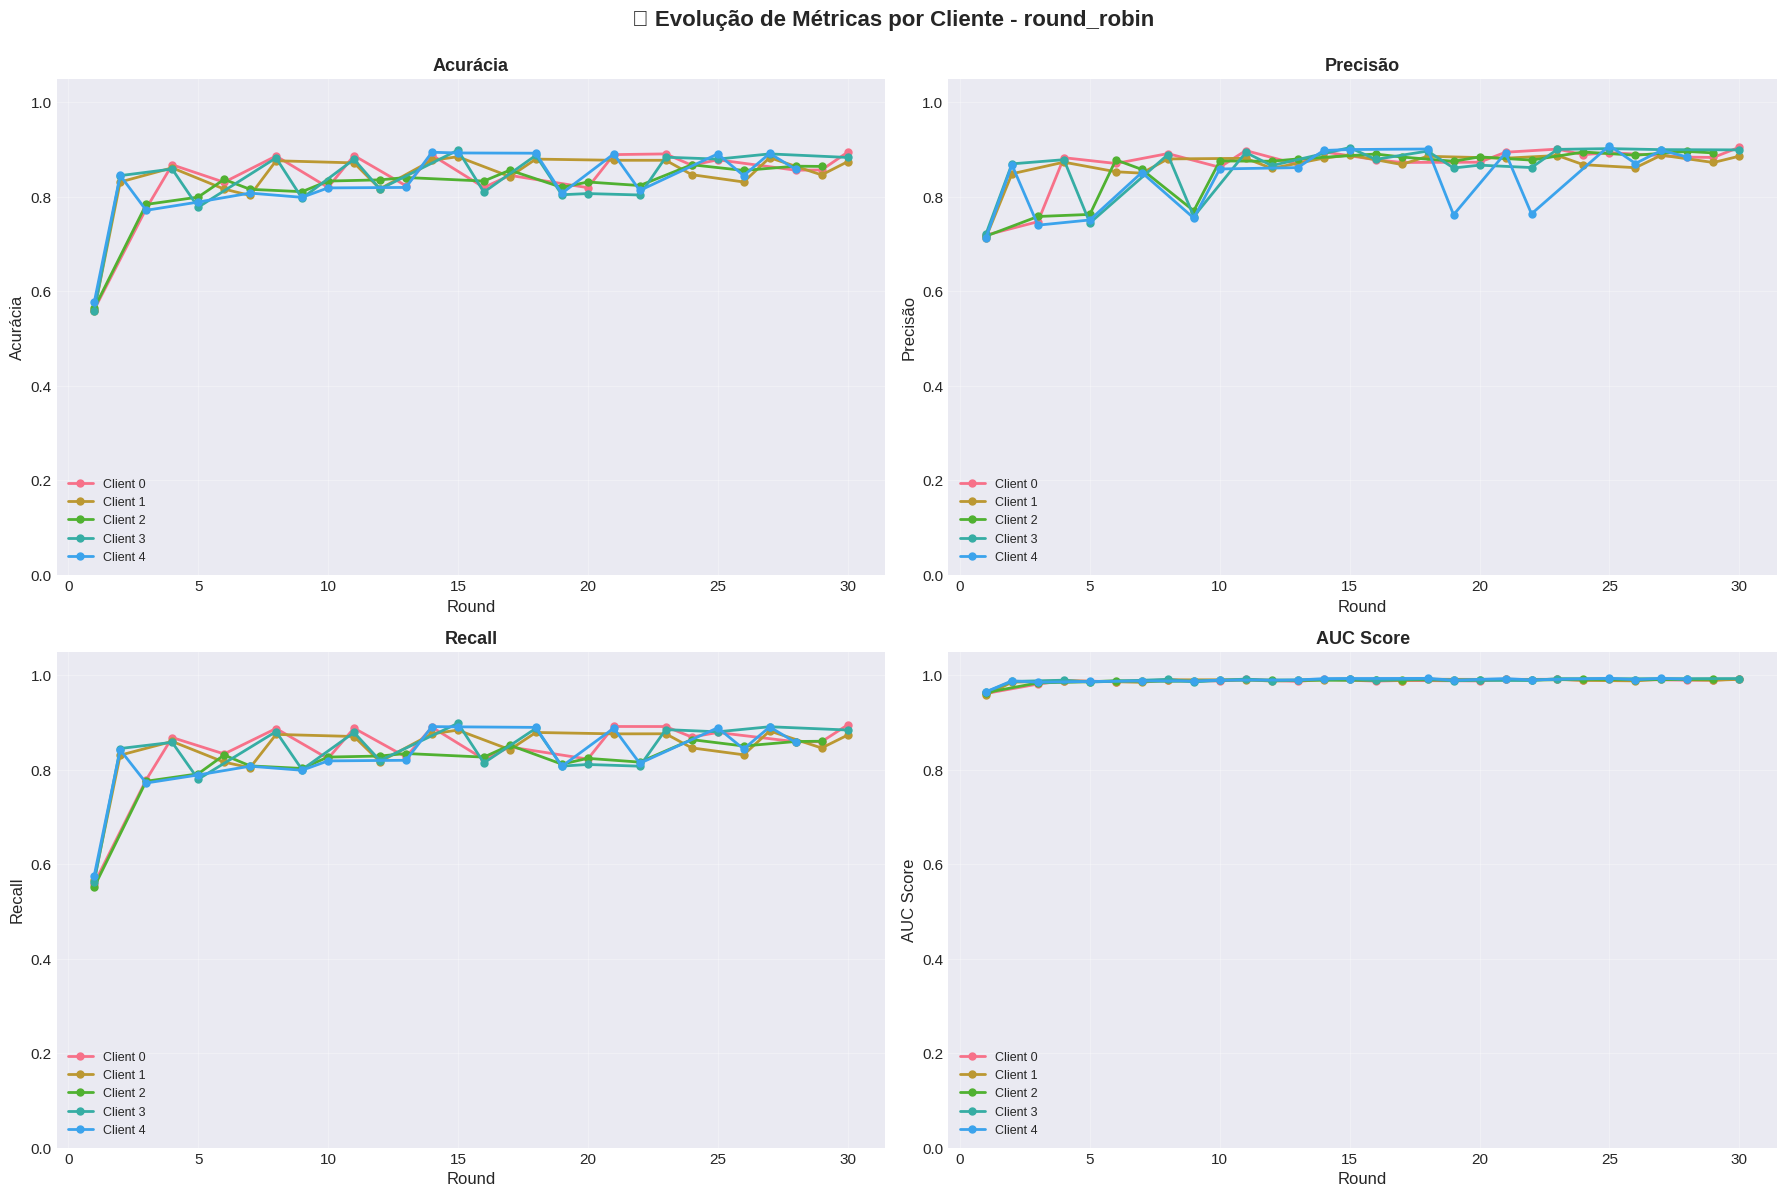

In [ ]:
if client_df is not None:
    # Plotar evolução de múltiplas métricas de cada cliente ao longo do tempo
    experiments_to_plot = sorted(client_df["experiment"].unique())

    # Métricas a plotar
    metrics_to_plot = [
        ("eval_test_accuracy", "Acurácia", "#2E86AB"),
        ("eval_test_precision", "Precisão", "#A23B72"),
        ("eval_test_recall", "Recall", "#F18F01"),
        ("eval_test_auc", "AUC Score", "#06A77D"),
    ]

    for experiment in experiments_to_plot:
        exp_data = client_df[client_df["experiment"] == experiment]

        # Criar subplots: 2 linhas, 2 colunas (grid 2x2 para 4 métricas)
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(
            f"📈 Evolução de Métricas por Cliente - {experiment}",
            fontsize=16,
            fontweight="bold",
            y=0.995,
        )

        axes = axes.flatten()

        for idx, (metric, label, color) in enumerate(metrics_to_plot):  # noqa: B007
            ax = axes[idx]

            for cid in sorted(exp_data["cid"].unique()):
                client_data = exp_data[exp_data["cid"] == cid].sort_values("rounds")
                ax.plot(
                    client_data["rounds"],
                    client_data[metric],
                    marker="o",
                    label=f"Client {cid}",
                    linewidth=2,
                    markersize=5,
                )

            ax.set_xlabel("Round", fontsize=12)
            ax.set_ylabel(label, fontsize=12)
            ax.set_title(f"{label}", fontsize=13, fontweight="bold")
            ax.legend(loc="best", fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])  # Normalizar escala para todas as métricas

        plt.tight_layout()

        # Sanitizar nome do experimento para o filename
        safe_exp_name = experiment.replace("/", "-").replace(" ", "-")
        plt.savefig(
            output_dir / f"topico-7-evolucao-metricas-clientes-{safe_exp_name}.png",
            dpi=300,
            bbox_inches="tight",
        )
        print(f"💾 Salvo: topico-7-evolucao-metricas-clientes-{safe_exp_name}.png")
        plt.show()

## 8️⃣ Comparação Entre Estratégias


In [ ]:
# Criar tabela comparativa final
print("=" * 80)
print("📋 TABELA COMPARATIVA FINAL")
print("=" * 80)

comparison_table = []

for experiment in sorted(server_df["experiment"].unique()):
    exp_data = server_df[server_df["experiment"] == experiment]

    # Pegar métricas finais
    final_metrics = exp_data.iloc[-1]

    # Calcular melhorias
    initial_acc = exp_data["accuracy"].iloc[0]
    final_acc = final_metrics["accuracy"]
    improvement = final_acc - initial_acc

    # Fairness
    if experiment in selection_analysis:
        fairness_data = fairness_df[fairness_df["experiment"] == experiment].iloc[0]
        cv = fairness_data["cv"]
        gini = fairness_data["gini_coefficient"]
    else:
        cv = None
        gini = None

    comparison_table.append(
        {
            "Experimento": experiment,
            "Seleção": final_metrics["selection_method"],
            "Agregação": final_metrics["aggregation_method"],
            "Treinamento": final_metrics["training_method"],
            "Rounds": len(exp_data),
            "Acc Inicial": f"{initial_acc:.4f}",
            "Acc Final": f"{final_acc:.4f}",
            "Melhoria": f"{improvement:.4f}",
            "F1-Score Final": f"{final_metrics['f1_score']:.4f}",
            "AUC Final": f"{final_metrics['auc']:.4f}",
            "Loss Final": f"{final_metrics['loss']:.4f}",
            "CV Fairness": f"{cv:.4f}" if cv is not None else "N/A",
            "Gini": f"{gini:.4f}" if gini is not None else "N/A",
        }
    )

comparison_df = pd.DataFrame(comparison_table)
comparison_df = comparison_df.sort_values("Acc Final", ascending=False)

display(comparison_df)

# Salvar tabela comparativa como imagem
fig, ax = plt.subplots(figsize=(18, len(comparison_df) * 0.6 + 1))
ax.axis("tight")
ax.axis("off")
table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1, 1.8)
# Colorir header
for i in range(len(comparison_df.columns)):
    table[(0, i)].set_facecolor("#4CAF50")
    table[(0, i)].set_text_props(weight="bold", color="white")
plt.title(
    "Topico 8 - Tabela Comparativa Final de Todos os Experimentos",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.savefig(output_dir / "topico-8-tabela-comparativa-final.png", dpi=300, bbox_inches="tight")
plt.close()
print("💾 Salvo: topico-8-tabela-comparativa-final.png")

# Exportar para CSV
output_path = "../logs/comparison_summary.csv"
comparison_df.to_csv(output_path, index=False)
print(f"\n✅ Tabela comparativa salva em: {output_path}")

📋 TABELA COMPARATIVA FINAL


,Experimento,Seleção,Agregação,Treinamento,Rounds,Acc Inicial,Acc Final,Melhoria,F1-Score Final,AUC Final,Loss Final,CV Fairness,Gini
8,round_robin,round_robin,fedavg,normal,30,0.5634,0.8751,0.3117,0.8751,0.9923,0.3346,0.0298,0.0130
7,random,random,fedavg,normal,30,0.5634,0.8725,0.3091,0.8695,0.9921,0.3502,0.0987,0.0478
5,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,letsfed,letsfed,letsfed,30,0.2534,0.8698,0.6164,0.8663,0.9917,0.3566,0.2992,0.1261
2,letsfed_f1score_85_thr,letsfed,fedavg,letsfed,30,0.2534,0.8697,0.6163,0.8650,0.9915,0.3477,0.2761,0.1217
4,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,letsfed,letsfed,letsfed,30,0.5634,0.8603,0.2969,0.8563,0.9914,0.3891,0.2126,0.1000
3,letsfed_f1score_90_thr,letsfed,fedavg,letsfed,30,0.2534,0.8214,0.5680,0.8083,0.9853,0.7649,0.1191,0.0522
6,poc,poc,fedavg,normal,30,0.2534,0.8213,0.5679,0.8101,0.9859,0.6824,1.1554,0.5063
0,letsfed_accuracy_100_thr,letsfed,fedavg,letsfed,30,0.5634,0.8182,0.2548,0.8048,0.9792,1.2020,0.1701,0.0783
1,letsfed_accuracy_90_thr,letsfed,fedavg,letsfed,30,0.5634,0.8171,0.2537,0.8020,0.9842,0.7815,0.1191,0.0522


💾 Salvo: topico-8-tabela-comparativa-final.png

✅ Tabela comparativa salva em: ../logs/comparison_summary.csv


💾 Salvo: topico-8-heatmap-metricas-normalizadas.png


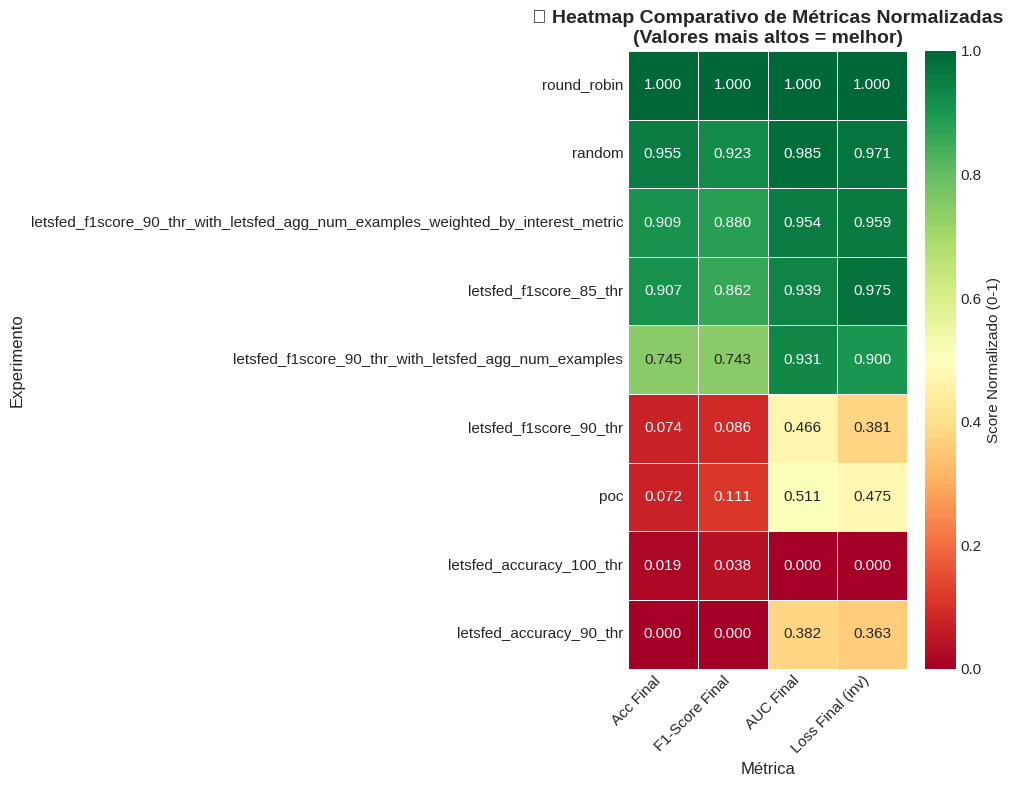

In [ ]:
# Criar heatmap de métricas normalizadas
from sklearn.preprocessing import MinMaxScaler

# Preparar dados para heatmap
heatmap_data = comparison_df[["Experimento", "Acc Final", "F1-Score Final", "AUC Final"]].copy()
heatmap_data["Loss Final"] = comparison_df["Loss Final"]

# Converter strings para float
for col in ["Acc Final", "F1-Score Final", "AUC Final", "Loss Final"]:
    heatmap_data[col] = heatmap_data[col].astype(float)

# Inverter loss (quanto menor, melhor)
heatmap_data["Loss Final (inv)"] = 1 / (1 + heatmap_data["Loss Final"])
heatmap_data = heatmap_data.drop("Loss Final", axis=1)

# Normalizar
scaler = MinMaxScaler()
numeric_cols = heatmap_data.columns[1:]
heatmap_data[numeric_cols] = scaler.fit_transform(heatmap_data[numeric_cols])

# Plotar heatmap
plt.figure(figsize=(10, 8))
heatmap_matrix = heatmap_data.set_index("Experimento")[numeric_cols]

sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    cbar_kws={"label": "Score Normalizado (0-1)"},
    linewidths=0.5,
)
plt.title(
    "🔥 Heatmap Comparativo de Métricas Normalizadas\n(Valores mais altos = melhor)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Experimento", fontsize=12)
plt.xlabel("Métrica", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "topico-8-heatmap-metricas-normalizadas.png", dpi=300, bbox_inches="tight")
print("💾 Salvo: topico-8-heatmap-metricas-normalizadas.png")
plt.show()

## 9️⃣ Conclusões e Recomendações


📝 CONCLUSÕES E RECOMENDAÇÕES

🎯 Criando gráfico radar para comparação multidimensional...

📊 Scores de Balanceamento (área média do polígono):


,experiment,polygon_area
8,round_robin,0.881492
5,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,0.872684
2,letsfed_f1score_85_thr,0.872615
7,random,0.834037
4,letsfed_f1score_90_thr_with_letsfed_agg_num_ex...,0.717676
3,letsfed_f1score_90_thr,0.495044
1,letsfed_accuracy_90_thr,0.346541
6,poc,0.253936
0,letsfed_accuracy_100_thr,0.206805


💾 Salvo: topico-9-radar-top5-experimentos.png


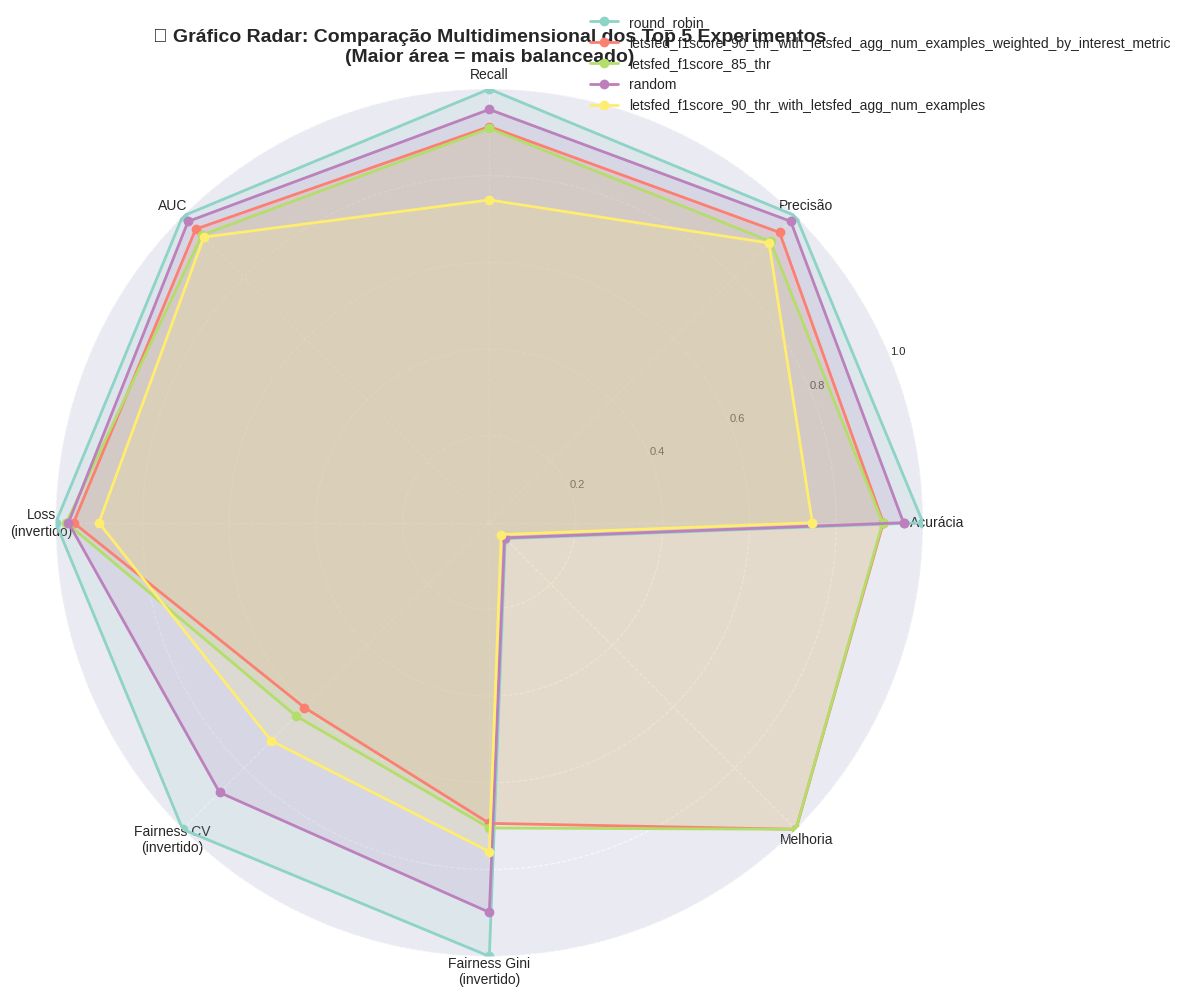

💾 Salvo: topico-9-radar-todos-experimentos-grid.png


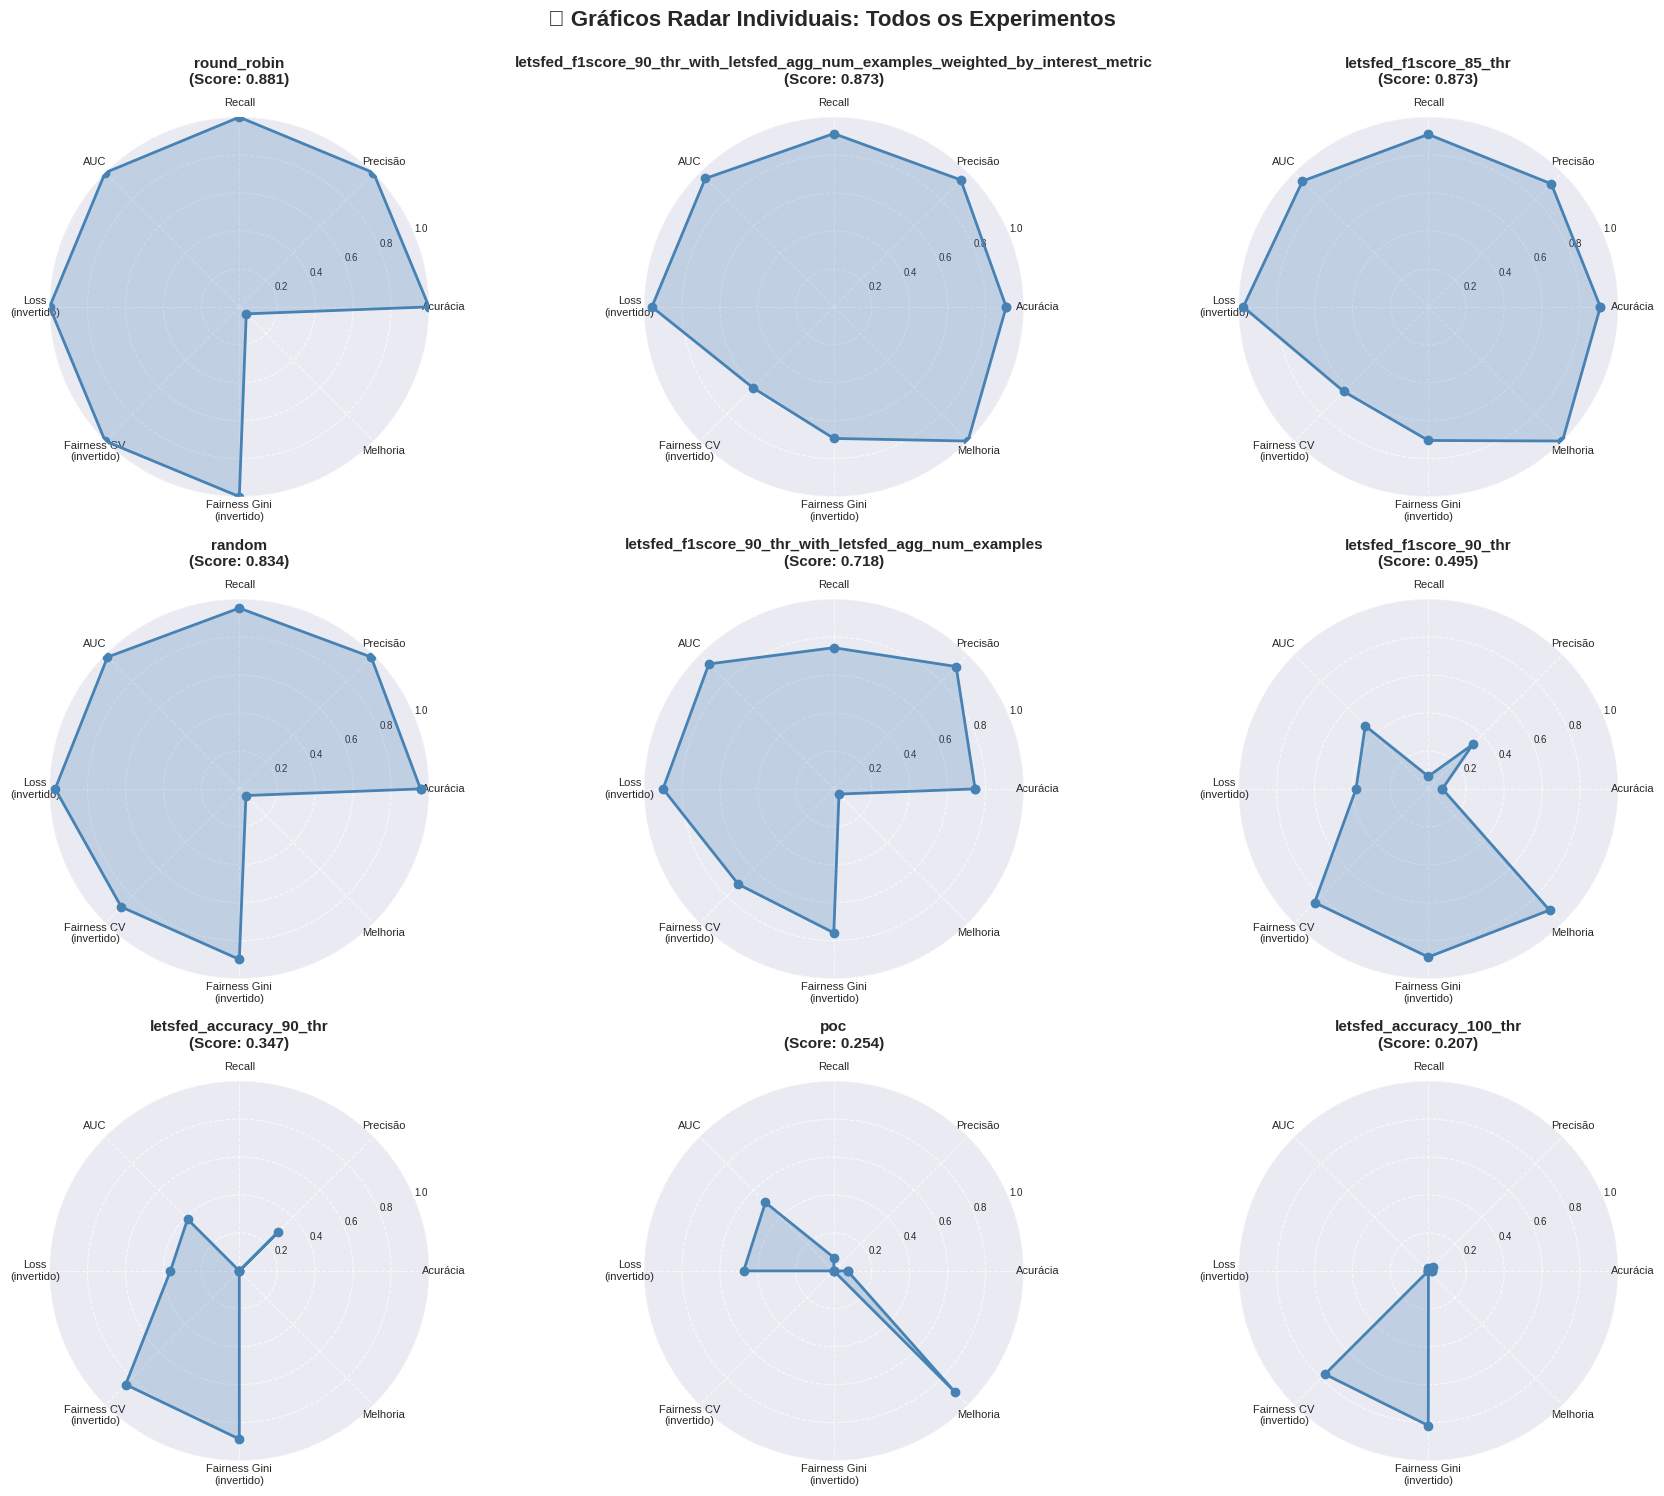


✅ Gráficos radar gerados!
💾 Salvo: topico-9-tabela-scores-balanceamento.png

🏆 EXPERIMENTO MAIS BALANCEADO (maior área no radar):
   Experimento: round_robin
   Score de Balanceamento: 0.8815

🎯 MELHOR ACURÁCIA:
   Experimento: round_robin
   Acurácia Final: 0.8751
   F1-Score: 0.8751

⚖️ MELHOR FAIRNESS:
   Experimento: round_robin
   Coeficiente de Variação: 0.0298
   Coeficiente de Gini: 0.0130

🚀 MAIOR MELHORIA:
   Experimento: letsfed_f1score_90_thr_with_letsfed_agg_num_examples_weighted_by_interest_metric
   Melhoria: 0.6164

💡 RECOMENDAÇÕES:

1. Para SOLUÇÃO BALANCEADA: Use 'round_robin' (melhor área no radar)
2. Para ALTA ACURÁCIA: Use 'round_robin' (melhor performance final)
3. Para FAIRNESS: Use 'round_robin' (distribuição mais justa)
4. Para CONVERGÊNCIA RÁPIDA: Use 'letsfed_f1score_90_thr_with_letsfed_agg_num_examples_weighted_by_interest_metric' (maior melhoria)
5. Para CENÁRIOS NÃO-IID: Considere estratégias específicas (LetsFed, MaxFL, QFFL)
6. REPRODUTIBILIDADE: Sempre

In [ ]:
print("=" * 80)
print("📝 CONCLUSÕES E RECOMENDAÇÕES")
print("=" * 80)

# ====================================================================
# 📊 GRÁFICO RADAR MULTIDIMENSIONAL
# ====================================================================

print("\n🎯 Criando gráfico radar para comparação multidimensional...")

# Preparar dados para o radar chart
radar_data = []

for experiment in sorted(server_df["experiment"].unique()):
    exp_data = server_df[server_df["experiment"] == experiment]
    final_metrics = exp_data.iloc[-1]
    initial_metrics = exp_data.iloc[0]

    # Métricas finais
    accuracy = final_metrics["accuracy"]
    precision = final_metrics["precision"]
    recall = final_metrics["recall"]
    auc = final_metrics["auc"]
    loss = final_metrics["loss"]

    # Melhoria (métrica final / inicial) - quanto maior, melhor
    improvement_ratio = (
        accuracy / initial_metrics["accuracy"] if initial_metrics["accuracy"] > 0 else 1.0
    )

    # Fairness (quanto menor CV e Gini, melhor - vamos inverter para normalização)
    if experiment in selection_analysis:
        fairness_data = fairness_df[fairness_df["experiment"] == experiment].iloc[0]
        cv = fairness_data["cv"]
        gini = fairness_data["gini_coefficient"]
    else:
        cv = 1.0
        gini = 1.0

    radar_data.append(
        {
            "experiment": experiment,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "auc": auc,
            "loss_inv": 1 / (1 + loss),  # Inverter loss (quanto menor, melhor)
            "cv_inv": 1 / (1 + cv),  # Inverter CV (quanto menor, melhor)
            "gini_inv": 1 / (1 + gini),  # Inverter Gini (quanto menor, melhor)
            "improvement": improvement_ratio,
        }
    )

radar_df = pd.DataFrame(radar_data)

# Normalizar todas as métricas para escala 0-1
from sklearn.preprocessing import MinMaxScaler  # noqa: E402

scaler = MinMaxScaler()
metrics_cols = [
    "accuracy",
    "precision",
    "recall",
    "auc",
    "loss_inv",
    "cv_inv",
    "gini_inv",
    "improvement",
]
radar_df[metrics_cols] = scaler.fit_transform(radar_df[metrics_cols])

# Calcular área do polígono (métrica de balanceamento)
radar_df["polygon_area"] = radar_df[metrics_cols].mean(axis=1)
radar_df = radar_df.sort_values("polygon_area", ascending=False)

print("\n📊 Scores de Balanceamento (área média do polígono):")
display(radar_df[["experiment", "polygon_area"]].head(10))

# Criar gráfico de radar
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402

# Configurações
categories = [
    "Acurácia",
    "Precisão",
    "Recall",
    "AUC",
    "Loss\n(invertido)",
    "Fairness CV\n(invertido)",
    "Fairness Gini\n(invertido)",
    "Melhoria",
]
N = len(categories)

# Ângulos para cada eixo
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Completar o círculo

# Plotar top 5 experimentos mais balanceados
top_experiments = radar_df.head(5)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection="polar"))  # noqa: C408

# Cores distintas
colors = plt.cm.Set3(np.linspace(0, 1, len(top_experiments)))

for idx, (_, row) in enumerate(top_experiments.iterrows()):
    values = row[metrics_cols].tolist()
    values += values[:1]  # Completar o polígono

    ax.plot(angles, values, "o-", linewidth=2, label=row["experiment"], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Configurações do gráfico
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=8)
ax.grid(True, linestyle="--", alpha=0.7)

plt.title(
    "🎯 Gráfico Radar: Comparação Multidimensional dos Top 5 Experimentos\n(Maior área = mais balanceado)",  # noqa: E501
    size=14,
    fontweight="bold",
    pad=20,
)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "topico-9-radar-top5-experimentos.png", dpi=300, bbox_inches="tight")
print("💾 Salvo: topico-9-radar-top5-experimentos.png")
plt.show()

# Criar gráfico de radar com TODOS os experimentos (em grid)
num_experiments = len(radar_df)
ncols = 3
nrows = (num_experiments + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), subplot_kw=dict(projection="polar"))  # noqa: C408
axes = axes.flatten() if num_experiments > 1 else [axes]

fig.suptitle(
    "🎯 Gráficos Radar Individuais: Todos os Experimentos", fontsize=16, fontweight="bold", y=0.995
)

for idx, (_, row) in enumerate(radar_df.iterrows()):
    ax = axes[idx]

    values = row[metrics_cols].tolist()
    values += values[:1]

    ax.plot(angles, values, "o-", linewidth=2, color="steelblue")
    ax.fill(angles, values, alpha=0.25, color="steelblue")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=7)
    ax.grid(True, linestyle="--", alpha=0.7)

    ax.set_title(
        f"{row['experiment']}\n(Score: {row['polygon_area']:.3f})",
        size=11,
        fontweight="bold",
        pad=10,
    )

# Remover eixos extras
for idx in range(num_experiments, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(output_dir / "topico-9-radar-todos-experimentos-grid.png", dpi=300, bbox_inches="tight")
print(f"💾 Salvo: topico-9-radar-todos-experimentos-grid.png")  # noqa: F541
plt.show()

print("\n✅ Gráficos radar gerados!")

# Salvar tabela de scores de balanceamento
fig, ax = plt.subplots(figsize=(12, len(radar_df) * 0.5 + 1))
ax.axis("tight")
ax.axis("off")
table_data = radar_df[["experiment", "polygon_area"]].round(4)
table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)
# Colorir header
for i in range(len(table_data.columns)):
    table[(0, i)].set_facecolor("#2196F3")
    table[(0, i)].set_text_props(weight="bold", color="white")
plt.title(
    "Topico 9 - Scores de Balanceamento (Área Média do Polígono Radar)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.savefig(output_dir / "topico-9-tabela-scores-balanceamento.png", dpi=300, bbox_inches="tight")
plt.close()
print("💾 Salvo: topico-9-tabela-scores-balanceamento.png")

# ====================================================================
# 📋 CONCLUSÕES TEXTUAIS
# ====================================================================

# Melhor experimento balanceado (maior área no radar)
best_balanced = radar_df.iloc[0]
print("\n🏆 EXPERIMENTO MAIS BALANCEADO (maior área no radar):")
print(f"   Experimento: {best_balanced['experiment']}")
print(f"   Score de Balanceamento: {best_balanced['polygon_area']:.4f}")

# Melhor acurácia
best_accuracy = comparison_df.iloc[0]
print("\n🎯 MELHOR ACURÁCIA:")
print(f"   Experimento: {best_accuracy['Experimento']}")
print(f"   Acurácia Final: {best_accuracy['Acc Final']}")
print(f"   F1-Score: {best_accuracy['F1-Score Final']}")

# Melhor fairness
if not fairness_df.empty:
    best_fairness = fairness_df.iloc[0]
    print("\n⚖️ MELHOR FAIRNESS:")
    print(f"   Experimento: {best_fairness['experiment']}")
    print(f"   Coeficiente de Variação: {best_fairness['cv']:.4f}")
    print(f"   Coeficiente de Gini: {best_fairness['gini_coefficient']:.4f}")

# Maior melhoria
comparison_df["Melhoria_float"] = comparison_df["Melhoria"].astype(float)
best_improvement = comparison_df.loc[comparison_df["Melhoria_float"].idxmax()]
print("\n🚀 MAIOR MELHORIA:")
print(f"   Experimento: {best_improvement['Experimento']}")
print(f"   Melhoria: {best_improvement['Melhoria']}")

print("\n" + "=" * 80)
print("💡 RECOMENDAÇÕES:")
print("=" * 80)
print(f"""
1. Para SOLUÇÃO BALANCEADA: Use '{best_balanced["experiment"]}' (melhor área no radar)
2. Para ALTA ACURÁCIA: Use '{best_accuracy["Experimento"]}' (melhor performance final)
3. Para FAIRNESS: Use '{best_fairness["experiment"] if not fairness_df.empty else "N/A"}' (distribuição mais justa)
4. Para CONVERGÊNCIA RÁPIDA: Use '{best_improvement["Experimento"]}' (maior melhoria)
5. Para CENÁRIOS NÃO-IID: Considere estratégias específicas (LetsFed, MaxFL, QFFL)
6. REPRODUTIBILIDADE: Sempre configure seeds fixas para resultados determinísticos

⚠️ PRÓXIMOS PASSOS:
- Executar experimentos com mais rounds para validar convergência
- Testar em diferentes datasets (CIFAR-10, MNIST, etc.)
- Validar em cenários com diferentes níveis de heterogeneidade
- Comparar com baselines da literatura
- Analisar trade-offs entre performance e fairness
""")  # noqa: E501

print("\n✅ Análise completa finalizada!")

## 🔟 FIM
